<a href="https://colab.research.google.com/github/animalwor1d/AFR-Project/blob/main/Gemma_two_step_fine_tuning(EA1%2C_EA2%2C_EA3%2C_EB5%2C_EB6%2C_additional_testing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your own computer, follow the installation instructions on our Github page [here](https://docs.unsloth.ai/get-started/installing-+-updating).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### Installation

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

### Unsloth

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.56G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

# LLaVA-one-step fine-tuning — Separately input images

# One-step fine-tuning settings

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = True,  # We support rank stabilized LoRA
    loftq_config = {}, # And LoftQ
    target_modules = "all-linear",    # Optional now! Can specify a list if needed
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


# Two-step fine-tuning settings

In [ ]:
from unsloth import FastVisionModel

# ================== LoRA injection (get_peft_model version) ==================

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,   # Inject LoRA into image projection layers
    finetune_language_layers   = True,   # Inject LoRA into language modules
    finetune_attention_modules = True,   # Q,K,V,O linear layers
    finetune_mlp_modules       = True,   # FFN (two linear layers)

    # -------- LoRA hyperparameters --------
    r            = 16,     # rank (e.g., 32 is suitable for ~50 few-shot samples)
    lora_alpha   = 16,     # α is usually set equal to rank
    lora_dropout = 0,      # Regularization, set ~0.2 for few-shot stability
    bias         = "none", # Usually unchanged
    random_state = 3407,
    use_rslora   = True,   # Enable rank-stable LoRA if desired
    loftq_config = {},     # LoftQ quantization (can be left empty)
    # target_modules = "all-linear",   # Default is all; use explicit list if only attention is needed
)

# Optional: print the number of linear layers with LoRA injected
print("LoRA layers injected:", len(model.peft_config["default"].target_modules))


LoRA layers injected: 343


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<a name="Data"></a>
### Data Prep


In [ ]:
from datasets import load_from_disk  # load a saved dataset

train_ds = load_from_disk("/content/drive/MyDrive/Colab Notebooks/train_vlm-twostep")  # training datasetA
val_ds   = load_from_disk("/content/drive/MyDrive/Colab Notebooks/val_vlm-twostep")    # validation datasetA
test_ds  = load_from_disk("/content/drive/MyDrive/Colab Notebooks/test_vlm-twostep")   # test datasetA
contrast150_vlm = load_from_disk("/content/drive/MyDrive/Colab Notebooks/contrast150_vlm") # 15 additional test models
train_vlm_contrast1000 = load_from_disk("/content/drive/MyDrive/Colab Notebooks/train_vlm_contrast1000-twostep") #training datasetB
test_vlm_contrast1000 = load_from_disk("/content/drive/MyDrive/Colab Notebooks/test_vlm_contrast1000-twostep") #test datasetB

In [ ]:
train_ds

Dataset({
    features: ['images', 'messages'],
    num_rows: 1800
})

Let's take a look at the dataset, and check what the 1st example shows:

In [ ]:
# images: list containing either image URLs or PIL.Image objects (shows the first sample)
train_ds[0]["images"]

[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>]

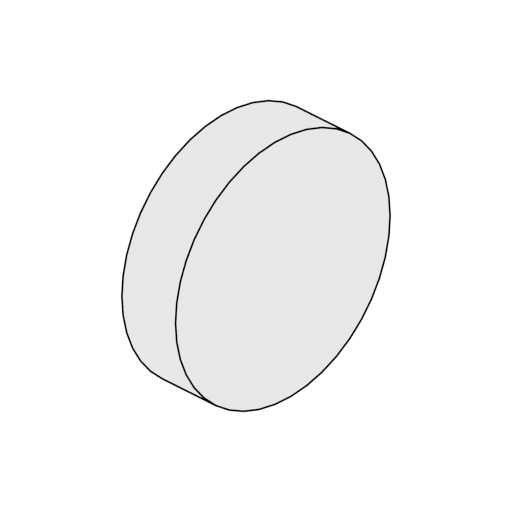

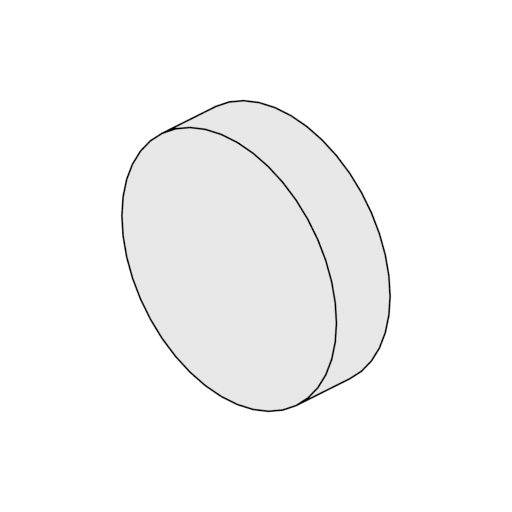

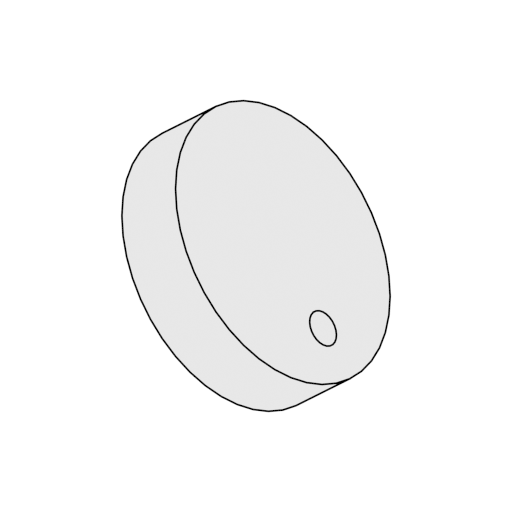

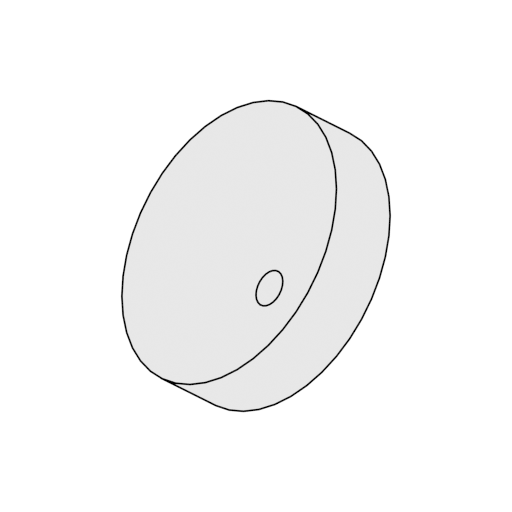

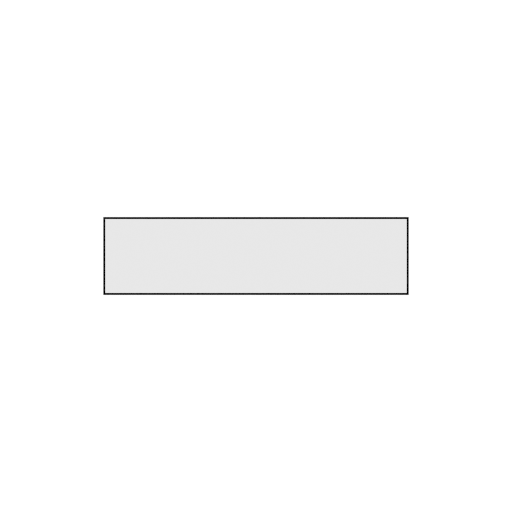

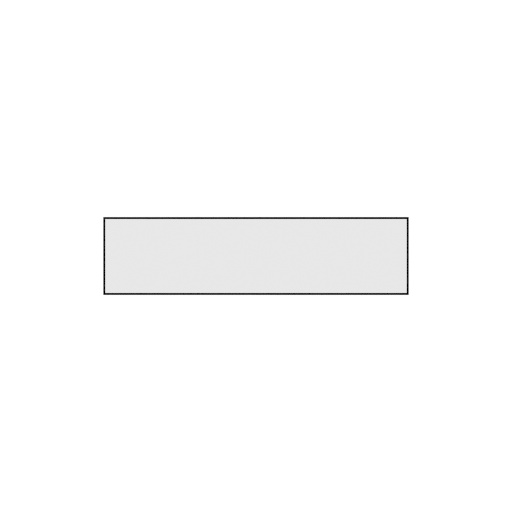

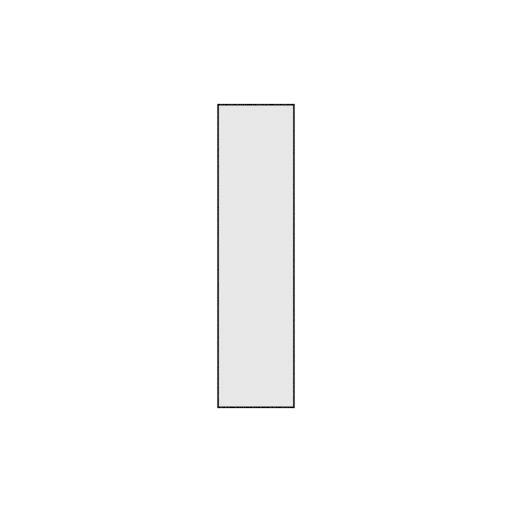

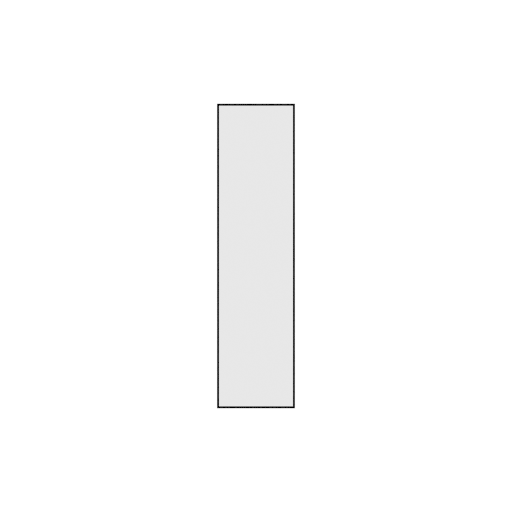

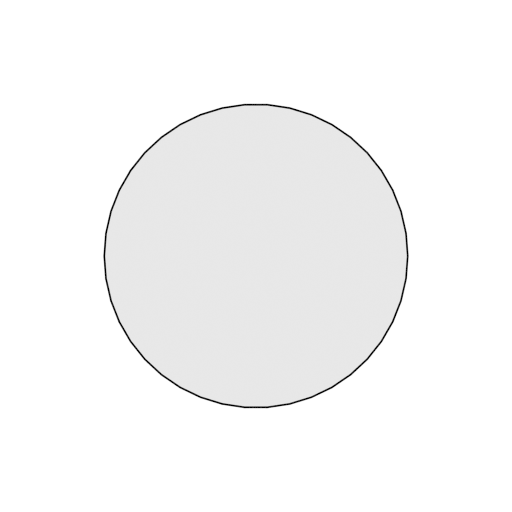

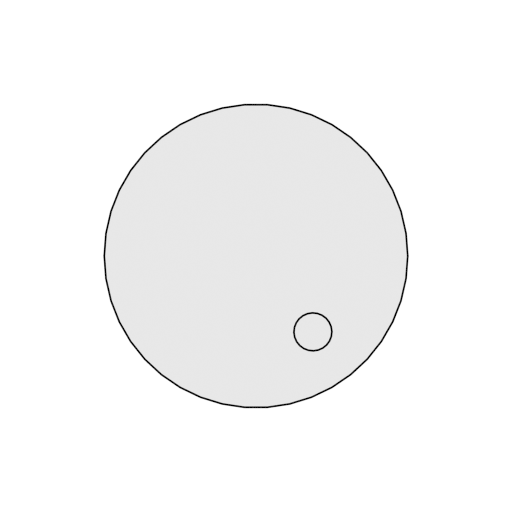

In [ ]:
from IPython.display import display

# Get the ten images from the first sample (list of URLs or PIL.Image objects)
imgs = train_ds[0]["images"]

# Display each image in the notebook (renders to the output cell)
for img in imgs:
    display(img)


In [ ]:
# Show the first record (dict) — contains 'images' (list) and 'messages' (list)
train_ds[0]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
  <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>],
 'messages': [{'content': [{'text': 'You will receive TEN fixed‐view images of a 3D‐CAD part.  \nYour task is to output ONLY the following JSON with exactly these six integer fields:\n- Hole_Through_count\n- Hole_Blind_count\n- Pocket_Opened_count\n- Pocket_Closed_count\n- Corner_Fillet_count\n- Corner_Chamfer_count\n====================

In [ ]:
sample = contrast150_vlm[0]
print(sample.keys())
# dict_keys(['images', 'messages'])

imgs = sample['images']
print(type(imgs), len(imgs))
# <class 'list'> 10

first_img = imgs[0]
print(type(first_img))
# <class 'PIL.Image.Image'>


dict_keys(['images', 'messages'])
<class 'list'> 10
<class 'PIL.PngImagePlugin.PngImageFile'>


In [ ]:

print(train_vlm_contrast1000["part_id"][:51])


[2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 28, 29, 30, 31, 33, 2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 28, 29, 30, 31, 33, 2, 3, 4, 7, 8, 11, 15, 19, 21, 23, 24, 26, 29, 30, 31, 32, 34]


In [ ]:
print(test_vlm_contrast1000["part_id"][:51])

[1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 32, 1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 28, 33, 1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 27, 32]


# Stitched image input format

In [ ]:
from datasets import Dataset
from PIL import Image

# ---------- Stitch 10 images into a single large grid image ----------
def stitch_images(img_list, cols=5, rows=2):
    """Arrange img_list[0..9] into a cols×rows grid while preserving resolution."""
    assert len(img_list) == cols * rows, "Exactly %d images required" % (cols * rows)
    w, h = img_list[0].size        # Assume each image is 512×512
    grid = Image.new("RGB", (w * cols, h * rows))
    for idx, img in enumerate(img_list):
        x = (idx % cols) * w
        y = (idx // cols) * h
        grid.paste(img, (x, y))
    return grid    # Output: 2560×1024

import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ───── Suppress logs & clear GPU memory ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON & output schema
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

def transform_groundtruth(
    flat_gt_json: str,
    manufacturing_features_names: str
) -> str:
    """
    Convert flat-format ground truth into an indented multi-line JSON string
    with "identified_features" structure, strictly matching the Example output format (4-space indentation).

    This version maps:
       'Through Hole'   → 'Hole_Through_count',
       'Blind Hole'     → 'Hole_Blind_count',
       'Opened Pocket'  → 'Pocket_Opened_count',
       'Closed Pocket'  → 'Pocket_Closed_count',
       'Chamfer'        → 'Corner_Chamfer_count',
       'Fillet'         → 'Corner_Fillet_count'.
    """
    flat_gt = json.loads(flat_gt_json)
    features_list = json.loads(manufacturing_features_names)

    new_gt = {"identified_features": []}
    for feat in features_list:
        name = feat["name"]              # e.g. "Through Hole"
        parts = name.split()             # e.g. ["Through","Hole"]

        # Decide feature type by last token and construct the correct flat key
        last = parts[-1]
        if last == "Hole":
            # Through Hole / Blind Hole
            flat_key = f"Hole_{parts[0]}_count"
        elif last == "Pocket":
            # Opened Pocket / Closed Pocket
            flat_key = f"Pocket_{parts[0]}_count"
        else:
            # Chamfer / Fillet → prefixed with Corner_
            flat_key = f"Corner_{name}_count"

        # Get value from flat JSON, default to 0
        count = flat_gt.get(flat_key, 0)
        exists = bool(count > 0)

        new_gt["identified_features"].append({
            "feature_name": name,
            "exists": exists,
            "quantity": count
        })

    return json.dumps(new_gt, indent=4)

# =========================================================
# 2) INST-format Prompt
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    # ① Stitch 10 images into one grid image
    grid_img = stitch_images(sample["images"], cols=5, rows=2)

    # ② Build user message: first text, then one image token
    user_content = [
        {"type": "text", "text": prompt_feature_recognition_3},
        {"type": "image", "image": grid_img}
    ]
    user_msg = {"role": "user", "content": user_content}

    # ③ Build assistant message: convert flat JSON to pretty indented JSON format
    raw_flat = sample["messages"][-1]["content"][0]["text"].strip()
    pretty_json = transform_groundtruth(raw_flat, manufacturing_features_names)
    assistant_msg = {
        "role": "assistant",
        "content": [{"type": "text", "text": pretty_json}]
    }

    return {"messages": [user_msg, assistant_msg]}


# DatasetA format conversion

In [ ]:
converted_list = [convert_to_conversation(sample) for sample in train_ds]

In [ ]:
val_dataset = [convert_to_conversation(sample) for sample in val_ds]

In [ ]:
test_dataset = [convert_to_conversation(sample) for sample in test_ds]

# Separately input images

In [ ]:
from datasets import Dataset
from PIL import Image
import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ───── Silent logs & clear GPU cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON & Output Schema
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

def transform_groundtruth(
    flat_gt_json: str,
    manufacturing_features_names: str
) -> str:
    """
    Convert flat-format ground-truth into `identified_features` structure,
    return as a multi-line indented JSON string (4 spaces), identical to
    Example output in the prompt.

    Mapping:
      'Through Hole'  → 'Hole_Through_count'
      'Blind Hole'    → 'Hole_Blind_count'
      'Opened Pocket' → 'Pocket_Opened_count'
      'Closed Pocket' → 'Pocket_Closed_count'
      'Chamfer'       → 'Corner_Chamfer_count'
      'Fillet'        → 'Corner_Fillet_count'
    """
    flat_gt = json.loads(flat_gt_json)
    features_list = json.loads(manufacturing_features_names)

    new_gt = {"identified_features": []}
    for feat in features_list:
        name = feat["name"]              # e.g. "Through Hole"
        parts = name.split()             # e.g. ["Through","Hole"]

        # Decide feature category based on the last word, then build the flat key
        last = parts[-1]
        if last == "Hole":
            # Through Hole / Blind Hole
            flat_key = f"Hole_{parts[0]}_count"
        elif last == "Pocket":
            # Opened Pocket / Closed Pocket
            flat_key = f"Pocket_{parts[0]}_count"
        else:
            # Chamfer or Fillet → prefix with Corner_
            flat_key = f"Corner_{name}_count"

        # Get value from flat JSON, default to 0
        count = flat_gt.get(flat_key, 0)
        exists = bool(count > 0)

        new_gt["identified_features"].append({
            "feature_name": name,
            "exists": exists,
            "quantity": count
        })

    return json.dumps(new_gt, indent=4)

# =========================================================
# 2) INST-format Prompt
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with multiple images of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    imgs: List[Image.Image] = sample["images"]
    assert imgs, "sample must contain at least one image"

    # (1) prompt itself contains no <image>
    content = [{"type": "text", "text": prompt_feature_recognition_3}]

    # (2) Insert only image elements, **do not** insert "<image>" text
    for img in imgs:
        content.append({"type": "image", "image": img})

    user_msg = {"role": "user", "content": content}

    # (3) assistant JSON
    raw_flat = sample["messages"][-1]["content"][0]["text"].strip()
    pretty_json = transform_groundtruth(raw_flat, manufacturing_features_names)

    assistant_msg = {
        "role": "assistant",
        "content": [{"type": "text", "text": pretty_json}],
    }
    return {"messages": [user_msg, assistant_msg]}


# DatasetB format conversion

In [ ]:
train_contrast1000_dataset = [convert_to_conversation(sample) for sample in train_vlm_contrast1000]

In [ ]:
test_contrast1000_dataset = [convert_to_conversation(sample) for sample in test_vlm_contrast1000]

# Stitched image input format - for 15 additional test models

In [ ]:
from datasets import Dataset
from PIL import Image

# ---------- Stitch 10 images into 1 large grid ----------
def stitch_images(img_list, cols=5, rows=2):
    """Stitch img_list[0..9] into a cols×rows grid, keeping original resolution."""
    assert len(img_list) == cols * rows, "Need exactly %d images" % (cols * rows)
    w, h = img_list[0].size        # Assume each image is 512×512
    grid = Image.new("RGB", (w * cols, h * rows))
    for idx, img in enumerate(img_list):
        x = (idx % cols) * w
        y = (idx // cols) * h
        grid.paste(img, (x, y))
    return grid    # Output size: 2560×1024

import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ───── Silence logs & clear GPU cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON (keep as-is)
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

# =========================================================
# 2) INST-format Prompt (note double braces escaping)
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function (no groundtruth, user-only message)
# =========================================================
IMAGE_TOKEN = "<image>"

def convert_to_conversation(sample: Dict) -> Dict:
    # (1) Stitch 10 images into one grid image
    grid_img = stitch_images(sample["images"], cols=5, rows=2)

    # (2) Build user message: text first, then one image
    user_content = [
        {"type": "text", "text": prompt_feature_recognition_3},
        {"type": "image", "image": grid_img}
    ]
    user_msg = {"role": "user", "content": user_content}

    # (3) Return (keep structure, remove assistant)
    return {
        "messages": [user_msg]
    }


# Separately input images - for 15 additional test models

In [ ]:
from datasets import Dataset
from PIL import Image
import os
import json
from typing import List, Dict
from PIL import Image
import torch
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from tqdm import tqdm

# ───── Silence logs & clear GPU cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()

# =========================================================
# 1) Feature JSON (keep as-is)
# =========================================================

manufacturing_features_names = '''[
  {
    "name": "Through Hole"
  },
  {
    "name": "Blind Hole"
  },
  {
    "name": "Opened Pocket"
  },
  {
    "name": "Closed Pocket"
  },
  {
    "name": "Chamfer"
  },
  {
    "name": "Fillet"
  }
]'''

# =========================================================
# 2) INST-format Prompt (note double braces escaping)
# =========================================================

prompt_feature_recognition_3 = f"""[INST]

You are provided with multiple images of a 3D CAD model taken from different viewing angles.
Your task is to identify and describe the manufacturing features present in this image.
Use the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:

'''{manufacturing_features_names}'''

Instructions:
1. **Go through the COMPLETE list of manufacturing features one by one.**
2. **Think about whether each particular feature exists in the given image.**
3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**
4. Examine **each views** of the part to identify all features. Different angles may reveal features not visible in other views.
5. For each feature, provide **Quantity:** The number of such features present in the image (e.g., if there are two "Through Holes", then quantity is 2). \
    This should be a numerical integer (0, 1, 2, ...).

Return the results in the following JSON format, strictly adhering to the specified structure, \
**Do not include any other content, including any punctuation around the text.**:

Example output:
{{
    "identified_features": [
        {{
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        }},
        {{
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        }},
        {{
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }}
    ]
}}
[/INST]"""

# =========================================================
# 3) Conversation conversion function (no groundtruth, user-only message)
# =========================================================
def convert_to_conversation(sample: Dict) -> Dict:
    """
    Generate only user message with images, no assistant reply.
    Use global prompt_feature_recognition_3 as text prompt.
    """
    imgs: List[Image.Image] = sample.get("images", [])
    if not imgs:
        raise ValueError("sample must contain at least one image")

    # Build user content: global prompt first, then each image
    user_content = [{"type": "text", "text": prompt_feature_recognition_3}]
    for img in imgs:
        user_content.append({"type": "image", "image": img})

    user_msg = {"role": "user", "content": user_content}

    return {"messages": [user_msg]}


# 15 additional test models format conversion

In [ ]:
contrast_dataset = [convert_to_conversation(sample) for sample in contrast150_vlm]

In [ ]:
converted_list[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
val_dataset[1]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
test_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

In [ ]:
train_contrast1000_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with multiple images of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views** of the part to ide

In [ ]:
test_contrast1000_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with multiple images of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views** of the part to ide

In [ ]:
contrast_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': '[INST]\n\nYou are provided with an image containing multiple views of a 3D CAD model taken from different viewing angles.\nYour task is to identify and describe the manufacturing features present in this image.\nUse the provided list of feature names, which is delimited by triple backticks. Use this list as a reference and strictly follow the naming conventions:\n\n\'\'\'[\n  {\n    "name": "Through Hole"\n  },\n  {\n    "name": "Blind Hole"\n  },\n  {\n    "name": "Opened Pocket"\n  },\n  {\n    "name": "Closed Pocket"\n  },\n  {\n    "name": "Chamfer"\n  },\n  {\n    "name": "Fillet"\n  }\n]\'\'\'\n\nInstructions:\n1. **Go through the COMPLETE list of manufacturing features one by one.**\n2. **Think about whether each particular feature exists in the given image.**\n3. **Answer the features based on the provided list, with the naming conventions strictly following the given list.**\n4. Examine **each views**

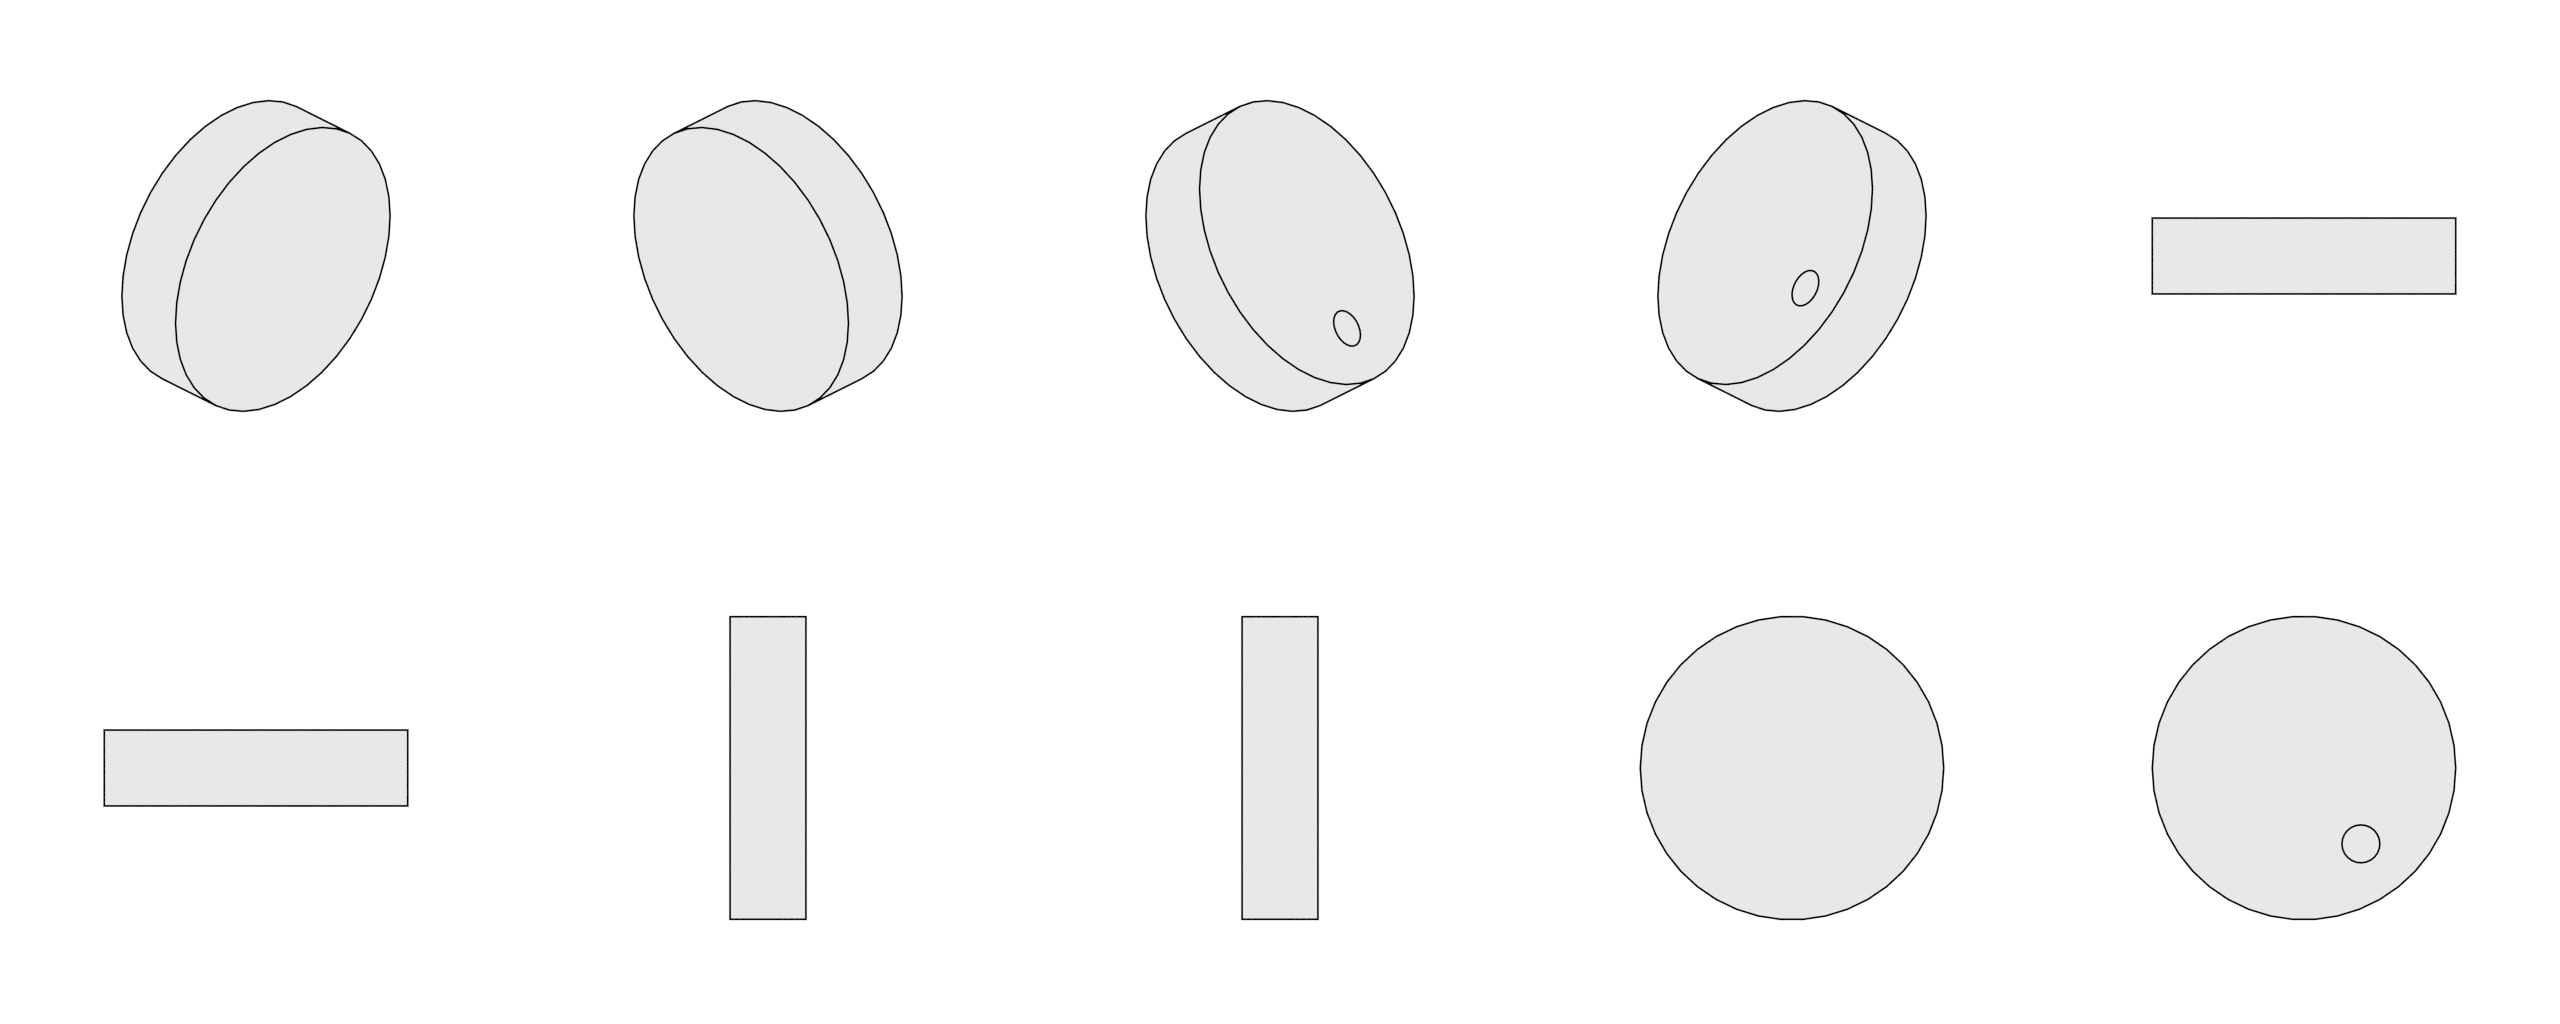

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list converted_list, or Dataset conv_ds
# Here we use converted_list as an example:
convo = converted_list[0]                       # first conversation
msg0  = convo["messages"][0]                    # first user message
img   = msg0["content"][1]["image"]             # extract the stitched grid image

# Method 1: directly display (Notebook/Colab)
display(img)


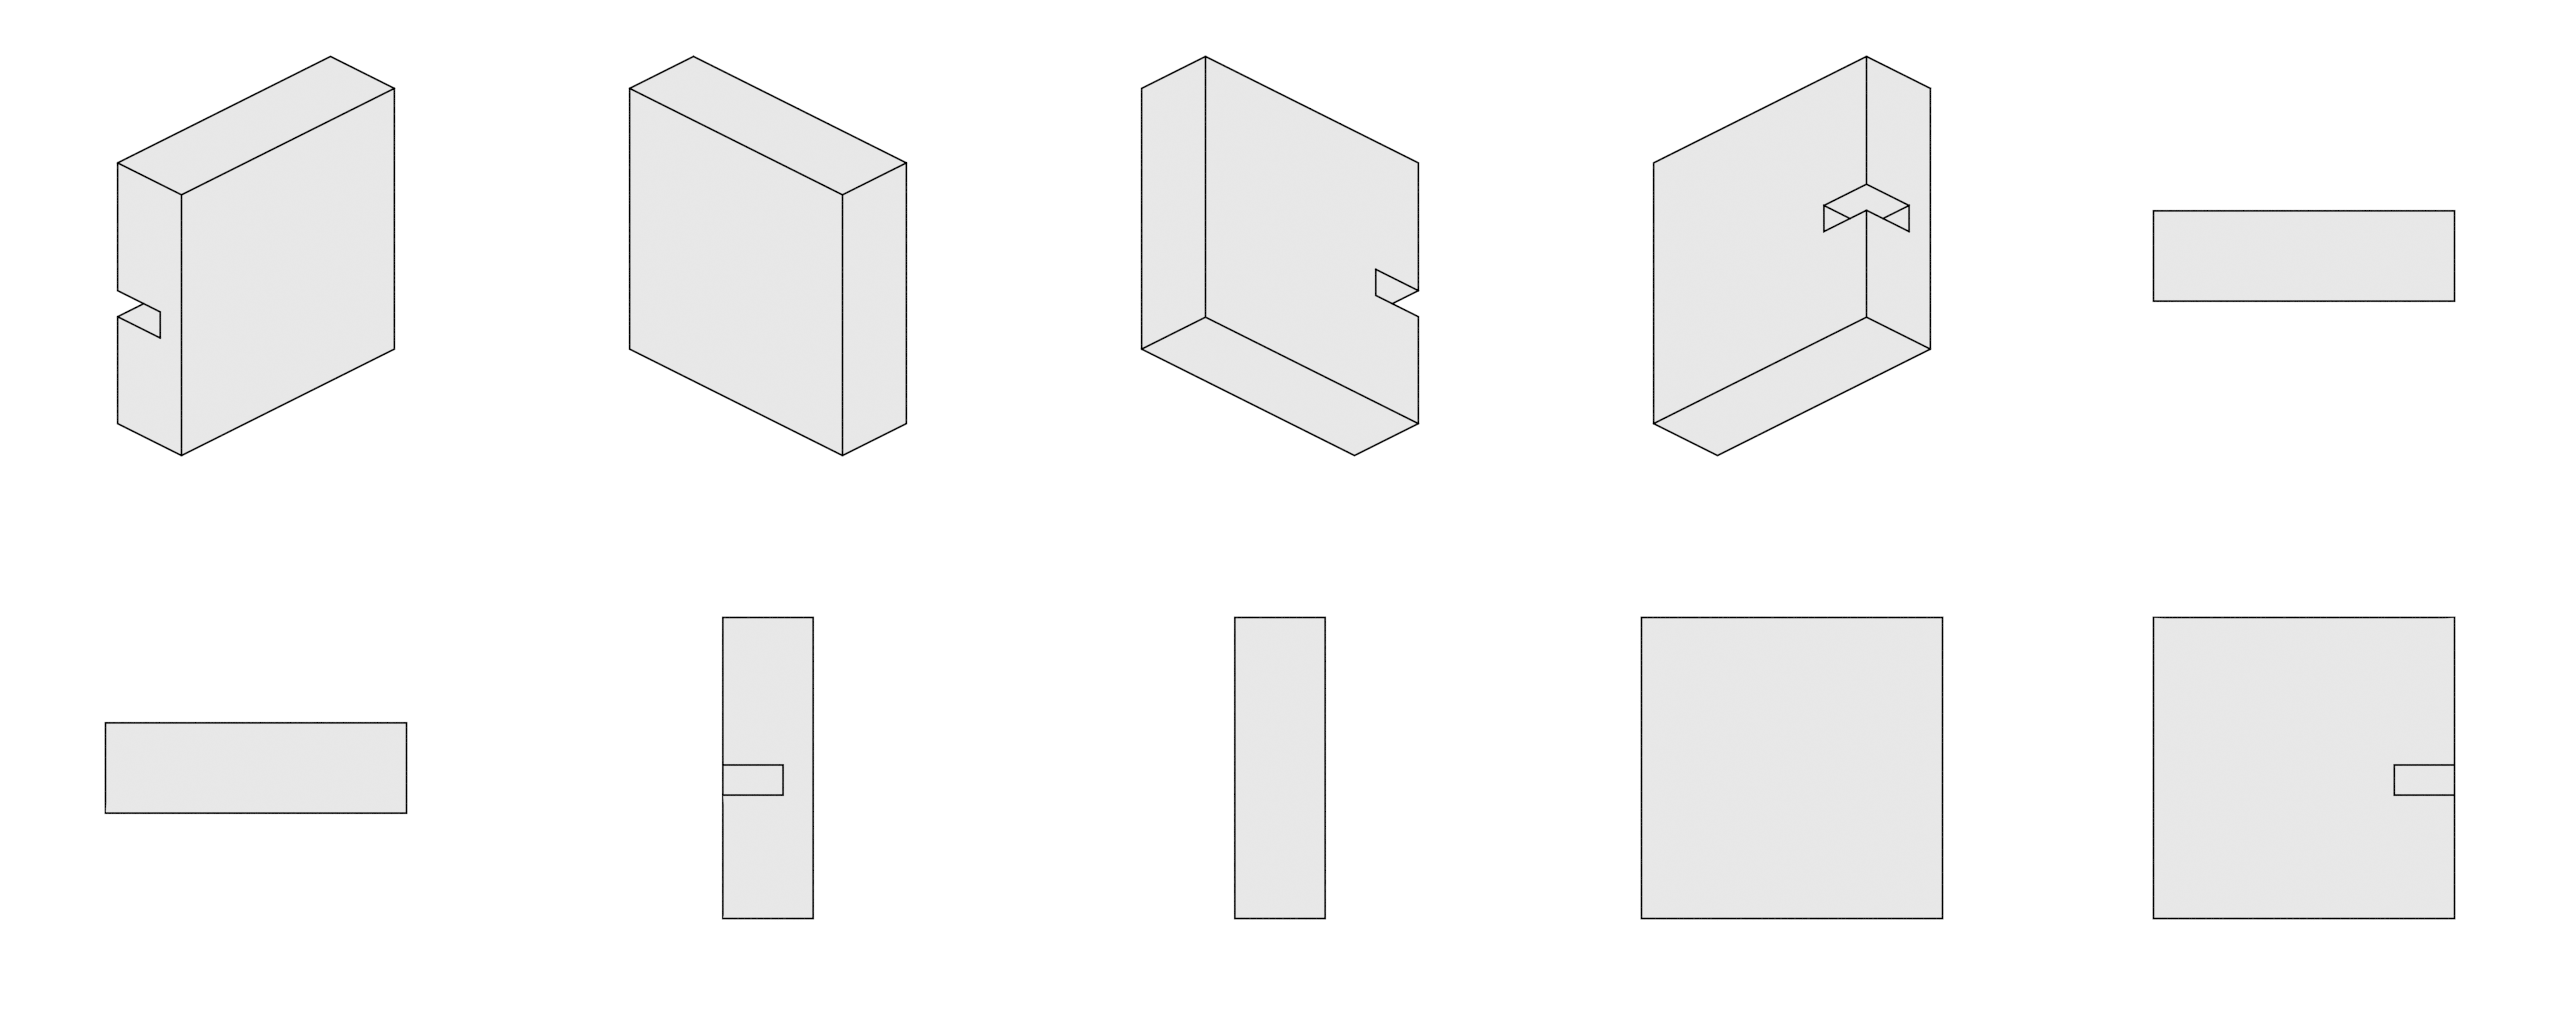

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list test_dataset, or Dataset conv_ds
# Here we use test_dataset as an example:
convo = test_dataset[0]                       # first conversation
msg0  = convo["messages"][0]                  # first user message
img   = msg0["content"][1]["image"]           # extract the stitched grid image

# Method 1: directly display (Notebook/Colab)
display(img)


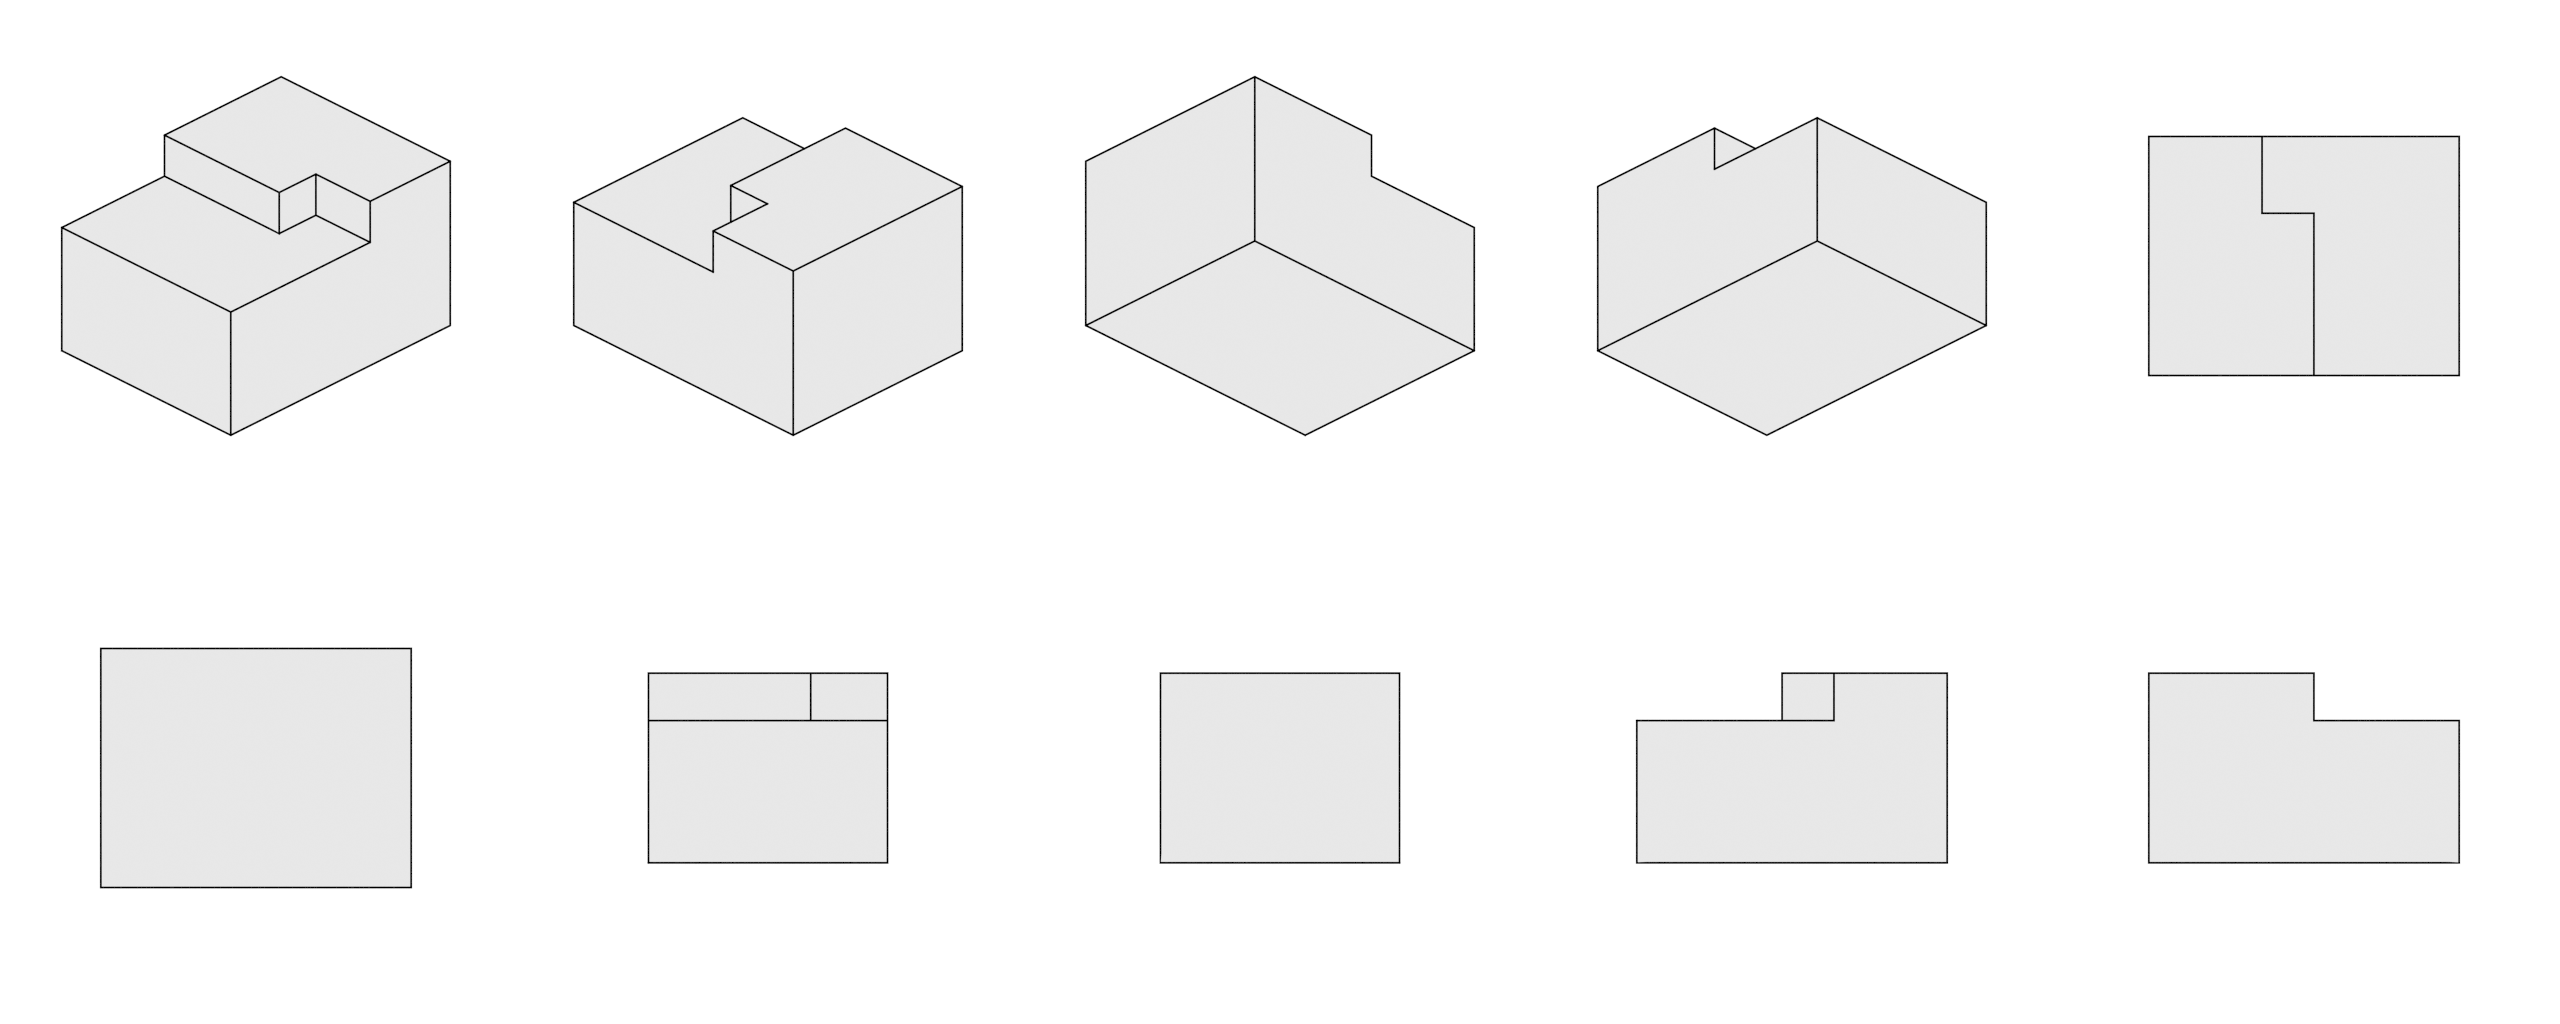

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list contrast_dataset, or Dataset conv_ds
# Here we use contrast_dataset as an example:
convo = contrast_dataset[0]                   # first conversation
msg0  = convo["messages"][0]                  # first user message
img   = msg0["content"][1]["image"]           # extract the stitched grid image

# Method 1: directly display (Notebook/Colab)
display(img)


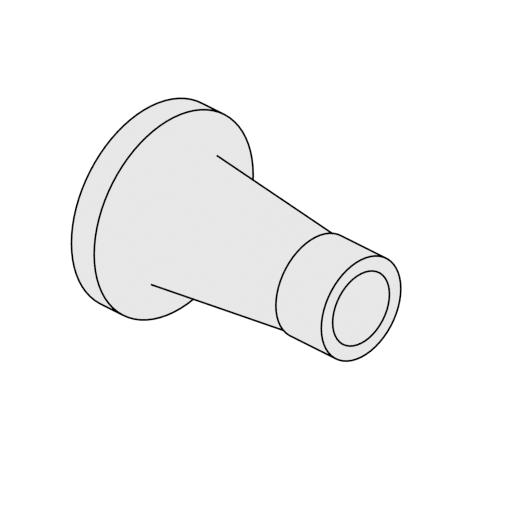

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Assume you have a list train_contrast1000_dataset, or Dataset conv_ds
# Here we use train_contrast1000_dataset as an example:
convo = train_contrast1000_dataset[17]         # first conversation
msg0  = convo["messages"][0]                   # first user message
img   = msg0["content"][1]["image"]            # extract the stitched grid image

# Method 1: directly display (Notebook/Colab)
display(img)


In [ ]:
pip install wandb

In [ ]:
wandb login

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: t18535178708 (t18535178708-the-university-of-edinburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Train the model

# one step fine-tuning

In [ ]:
# ======================== 0. Dependencies ========================
import torch
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

model.config.image_slots = 1                 # ← important

# ------------------------ 2. Enable training mode ------------------
FastVisionModel.for_training(model)   # freeze backbone and inject LoRA
model.config.use_cache = False        # disable cache for better training compatibility

tokenizer.model_max_length = 4096

# ------------------------ 3. Configure SFTConfig -------------------
sft_config = SFTConfig(
    # ----- Basic hyperparameters -----
    per_device_train_batch_size   = 8,          # mini-batch size per GPU
    gradient_accumulation_steps   = 2,          # accumulate 2 steps = effective batch 8 samples
    num_train_epochs              = 4,          # total 4 epochs
    warmup_ratio                  = 0.05,       # 5% warmup
    learning_rate                 = 1e-4,       # 0.0001
    logging_steps                 = 10,         # log every 10 steps
    optim                         = "adamw_torch_fused",
    weight_decay                  = 0.01,
    lr_scheduler_type             = "cosine",
    max_grad_norm = 0.3,
    seed                          = 3407,
    output_dir                    = "outputs",
    report_to                     = "none",      # change to "wandb" if using W&B

    gradient_checkpointing = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},

    # ----- Vision LoRA required -----
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages", # your sample text+image field name
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,
    max_length                    = 4096,

    # ----- Mixed precision & memory -----
    bf16                          = is_bfloat16_supported(),
    fp16                          = not is_bfloat16_supported(),

    # ----- Evaluation / saving strategy -----
    eval_strategy   = "steps",
    save_strategy   = "steps",
    eval_steps                    = 50,             # validate every 50 steps
    save_steps      = 50,                           # save model every 50 steps
    save_total_limit              = 4,              # keep at most 4 checkpoints
    load_best_model_at_end        = True,
    metric_for_best_model         = "eval_loss",
)


# ------------------------ 4. Build Trainer -----------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,               # combined Processor
    max_seq_length=4096,     # ← must align with SFTConfig
)

collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ------------------------ 4. Build Trainer -----------------
trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    data_collator = collator,
    train_dataset = converted_list,
    eval_dataset  = val_dataset,     # prepared validation dataset
    args          = sft_config,
)

#  Callback to print training + validation loss
from transformers import TrainerCallback

class SafeLossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            step = state.global_step
            if "loss" in logs and step % 10 == 0:
                print(f"📝 Step {step} | Training Loss: {logs['loss']:.4f}")
            if "eval_loss" in logs:
                print(f"✅ Step {step} | Eval Loss: {logs['eval_loss']:.4f}")

trainer.add_callback(SafeLossLogger())


Collator will resize images to: 896


In [ ]:
# Get a dataloader
train_dl = trainer.get_train_dataloader()
batch = next(iter(train_dl))

# Assume image tensors are stored in batch["pixel_values"]
# shape is usually (batch_size, image_slots, channels, H, W)
imgs = batch["pixel_values"]
print("Images tensor shape:", imgs.shape)
# Example: torch.Size([8, 1, 3, 512, 1280])


Images tensor shape: torch.Size([8, 3, 896, 896])


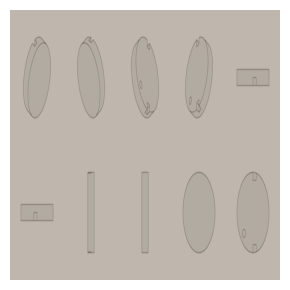

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Assume trainer is already built and model.config.image_slots is set
# Take one batch, get all slots from the first sample
batch = next(iter(trainer.get_train_dataloader()))
pv = batch["pixel_values"][0]           # shape: [num_slots, 3, H, W]
pv = pv.cpu().to(torch.float32)

# De-normalize (using CLIP mean/std; replace if using another processor)
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1)
pv = pv * std + mean                     # still [num_slots, 3, H, W]

# Clamp to [0,1]
pv = torch.clamp(pv, 0.0, 1.0)

# Create subplots dynamically based on number of slots
num_slots = pv.shape[0]
fig, axes = plt.subplots(1, num_slots, figsize=(3*num_slots, 3))
if num_slots == 1:
    axes = [axes]  # ensure axes is iterable

for i in range(num_slots):
    img = pv[i].permute(1,2,0).numpy()  # H × W × 3
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-40GB. Max memory = 39.557 GB.
4.504 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

{'loss': 1.5769, 'grad_norm': 2.1791603565216064, 'learning_rate': 3.91304347826087e-05, 'epoch': 0.08888888888888889}
📝 Step 10 | Training Loss: 1.5769
{'loss': 0.5734, 'grad_norm': 1.4493757486343384, 'learning_rate': 8.260869565217392e-05, 'epoch': 0.17777777777777778}
📝 Step 20 | Training Loss: 0.5734
{'loss': 0.0343, 'grad_norm': 0.1553269326686859, 'learning_rate': 9.995174328003631e-05, 'epoch': 0.26666666666666666}
📝 Step 30 | Training Loss: 0.0343
{'loss': 0.0066, 'grad_norm': 0.09592730551958084, 'learning_rate': 9.965717836263812e-05, 'epoch': 0.35555555555555557}
📝 Step 40 | Training Loss: 0.0066
{'loss': 0.0054, 'grad_norm': 0.1165071651339531, 'learning_rate': 9.909643486313533e-05, 'epoch': 0.4444444444444444}
📝 Step 50 | Training Loss: 0.0054
{'eval_loss': 0.005102862138301134, 'eval_runtime': 72.1948, 'eval_samples_per_second': 2.77, 'eval_steps_per_second': 0.693, 'epoch': 0.4444444444444444}
✅ Step 50 | Eval Loss: 0.0051
{'loss': 0.0051, 'grad_norm': 0.18877534568309

In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

4100.7525 seconds used for training.
68.35 minutes used for training.
Peak reserved memory = 13.113 GB.
Peak reserved memory for training = 8.609 GB.
Peak reserved memory % of max memory = 33.15 %.
Peak reserved memory for training % of max memory = 21.764 %.


In [ ]:
# After the first stage finishes, immediately get the best checkpoint
best_ckpt_1 = trainer.state.best_model_checkpoint
print("Stage 1 best ckpt:", best_ckpt_1)


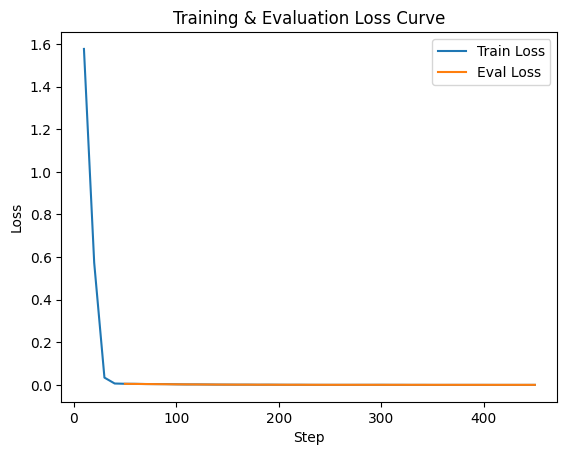

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

# trainer.train() has already finished

# 1. Convert logs to DataFrame
logs = trainer.state.log_history
df = pd.DataFrame(logs)

# 2. Separate training loss and evaluation loss
df_train = df[df['loss'].notnull()]
df_eval  = df[df['eval_loss'].notnull()]

# 3. Plot curves
plt.figure()
plt.plot(df_train['step'], df_train['loss'],  label='Train Loss')
plt.plot(df_eval['step'],  df_eval['eval_loss'], label='Eval Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training & Evaluation Loss Curve')
plt.legend()
plt.show()


# One-step fine-tuning model - Stitch image input

In [ ]:
# 1. Specify save path
output_path = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep"

# 2. Save current Trainer model weights (including LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. Save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Fully saved to {output_path}, directory includes model weights, tokenizer files, and training states such as optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth")


# Two-step fine-tuning - Stitching image input

In [ ]:
# ---------------------------------------------
# 1. Dependencies & Data Preparation
# ---------------------------------------------
import torch
from torch.utils.data import Dataset, ConcatDataset
from datasets import load_from_disk
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

# 1.1 Custom small list → Dataset
class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Assume train_contrast1000_dataset is already a list of 51 dicts
train_ds = ListDataset(train_contrast1000_dataset)
# 5× oversample
train_os = ConcatDataset([train_ds] * 5)

# ---------------------------------------------
# 2. Load first-stage model & enable training mode
# ---------------------------------------------
# 2.1 Load model (with LoRA adapter) from the previous saved directory
model, tokenizer = FastVisionModel.from_pretrained(
    model_name="/content/drive/MyDrive/fine_tuned_model-gemma-twostep",
    dtype=torch.bfloat16 if is_bfloat16_supported() else torch.float16,
    load_in_4bit=False,
)

# 2.2 Freeze backbone, train adapters only
FastVisionModel.for_training(model)
model.config.use_cache = False
tokenizer.model_max_length = 4096

# ---------------------------------------------
# 3. SFTConfig: hyperparameters & regularization
# ---------------------------------------------
sft_config = SFTConfig(
    # —— Small dataset: extend training & strong regularization ——
    num_train_epochs              = 5,       # run more epochs
    per_device_train_batch_size   = 8,       # small batch
    gradient_accumulation_steps   = 2,       # effective batch size = 16
    learning_rate                 = 2e-5,    # lower LR
    warmup_ratio                  = 0.1,     # 10% warmup
    optim                         = "adamw_torch_fused",
    weight_decay                  = 0.05,    # strong L2 regularization
    lr_scheduler_type             = "cosine",
    seed                          = 3407,
    output_dir                    = "outputs_phase2",
    report_to                     = "wandb",
    run_name="gemma-combopicture-step2",
    logging_steps                 = 1,
    max_grad_norm = 0.3,

    gradient_checkpointing = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},

    # —— Vision LoRA & data pipeline ——
    bf16                          = is_bfloat16_supported(),
    fp16                          = not is_bfloat16_supported(),
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages",
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,
    max_length                    = 4096,

    # —— Save & evaluation strategy (optionally add early stopping) ——
    save_strategy                 = "epoch",     # option: save every epoch
)

# ---------------------------------------------
# 4. Build DataCollator
# ---------------------------------------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,
    max_seq_length=4096,
)
collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ---------------------------------------------
# 5. Custom logging Callback
# ---------------------------------------------
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kw):
        if logs and "loss" in logs and state.global_step % args.logging_steps == 0:
            print(f"📝 Step {state.global_step} | Train Loss: {logs['loss']:.4f}")
        if logs and "eval_loss" in logs:
            print(f"✅ Step {state.global_step} | Eval Loss: {logs['eval_loss']:.4f}")

# ---------------------------------------------
# 6. Build Trainer & start training
# ---------------------------------------------
trainer = SFTTrainer(
    model           = model,
    tokenizer       = tokenizer,
    train_dataset   = train_os,
    data_collator   = collator,
    args            = sft_config,
)
trainer.add_callback(LossLogger())


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Collator will resize images to: 896


In [ ]:
# Get a dataloader
train_dl = trainer.get_train_dataloader()
batch = next(iter(train_dl))

# Assume image tensors are stored in batch["pixel_values"]
# shape is usually (batch_size, image_slots, channels, H, W)
imgs = batch["pixel_values"]
print("Images tensor shape:", imgs.shape)
# Example: torch.Size([8, 1, 3, 512, 1280])


Images tensor shape: torch.Size([8, 3, 896, 896])


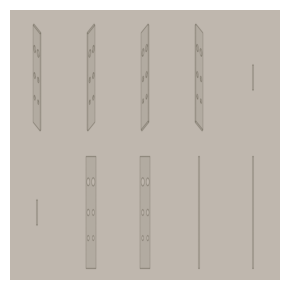

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Assume trainer is already built and model.config.image_slots is set
# Take one batch, get all slots from the first sample
batch = next(iter(trainer.get_train_dataloader()))
pv = batch["pixel_values"][0]           # shape: [num_slots, 3, H, W]
pv = pv.cpu().to(torch.float32)

# De-normalize (using CLIP mean/std; replace if using another processor)
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1)
pv = pv * std + mean                     # still [num_slots, 3, H, W]

# Clamp to [0,1]
pv = torch.clamp(pv, 0.0, 1.0)

# Create subplots dynamically based on number of slots
num_slots = pv.shape[0]
fig, axes = plt.subplots(1, num_slots, figsize=(3*num_slots, 3))
if num_slots == 1:
    axes = [axes]  # ensure axes is iterable

for i in range(num_slots):
    img = pv[i].permute(1,2,0).numpy()  # H × W × 3
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
trainer.train()

{'loss': 0.0318, 'grad_norm': 4.075977802276611, 'learning_rate': 0.0, 'epoch': 0.0625}
📝 Step 1 | Train Loss: 0.0318
{'loss': 0.0342, 'grad_norm': 4.059820652008057, 'learning_rate': 2.5e-06, 'epoch': 0.125}
📝 Step 2 | Train Loss: 0.0342
{'loss': 0.0224, 'grad_norm': 1.0273853540420532, 'learning_rate': 5e-06, 'epoch': 0.1875}
📝 Step 3 | Train Loss: 0.0224
{'loss': 0.0173, 'grad_norm': 0.788333535194397, 'learning_rate': 7.500000000000001e-06, 'epoch': 0.25}
📝 Step 4 | Train Loss: 0.0173
{'loss': 0.0173, 'grad_norm': 0.5516350269317627, 'learning_rate': 1e-05, 'epoch': 0.3125}
📝 Step 5 | Train Loss: 0.0173
{'loss': 0.0211, 'grad_norm': 0.5058941841125488, 'learning_rate': 1.25e-05, 'epoch': 0.375}
📝 Step 6 | Train Loss: 0.0211
{'loss': 0.0169, 'grad_norm': 0.3063104450702667, 'learning_rate': 1.5000000000000002e-05, 'epoch': 0.4375}
📝 Step 7 | Train Loss: 0.0169
{'loss': 0.0159, 'grad_norm': 1.1073530912399292, 'learning_rate': 1.7500000000000002e-05, 'epoch': 0.5}
📝 Step 8 | Train Lo

TrainOutput(global_step=80, training_loss=0.005995209392858669, metrics={'train_runtime': 708.1161, 'train_samples_per_second': 1.801, 'train_steps_per_second': 0.113, 'total_flos': 2.607675253294339e+16, 'train_loss': 0.005995209392858669})

In [ ]:
import wandb
wandb.finish()

train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
train/grad_norm,█▆▅▂▂▁▁▁▁▁▁▁▂▁▃▁▁▁▅▃▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▅▆▇███████▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▃▃▃▃▂▁▁▁▁▁▁▁▁▁
train/loss,█▆█▆▄▄▃▃▃▃▃▂▃▃▂▂▁▂▂▂▁▁▁▁▂▁▁▂▂▂▁▁▁▁▁▂▁▁▁▁
total_flos,2.607675253294339e+16
train/epoch,5
train/global_step,80
train/grad_norm,0.04982
train/learning_rate,0.0
train/loss,0.0015


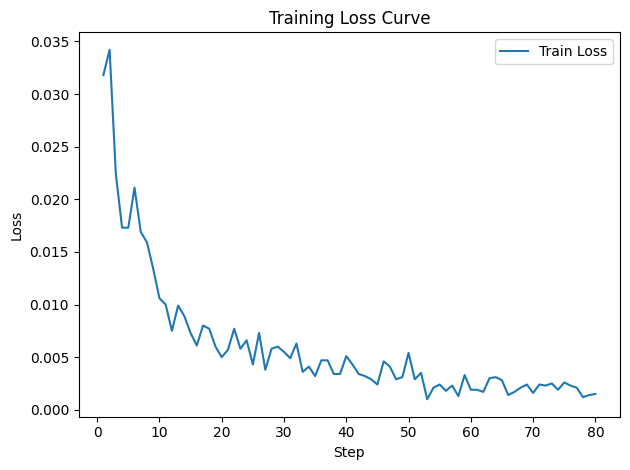

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# trainer.train() has finished
logs = trainer.state.log_history
df   = pd.DataFrame(logs)

# Keep only rows with loss
df_train = df[df["loss"].notnull()]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()


# Two-step fine-tuning model - stitching image input

In [ ]:
# 1. Specify save path
output_path = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-combinepicture"

# 2. Save current Trainer model weights (including LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. Save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Fully saved to {output_path}, directory includes model weights, tokenizer files, and training states such as optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth")


# Two-step fine-tuning - separate image input

In [ ]:
# ---------------------------------------------
# 1. Dependencies & Data Preparation
# ---------------------------------------------
import torch
from torch.utils.data import Dataset, ConcatDataset
from datasets import load_from_disk
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

# 1.1 Custom small list → Dataset
class ListDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Assume train_contrast1000_dataset is already a list of 51 dicts
train_ds = ListDataset(train_contrast1000_dataset)
# 5× oversample
train_os = ConcatDataset([train_ds] * 5)

# ---------------------------------------------
# 2. Load first-stage model & enable training mode
# ---------------------------------------------
# 2.1 Load model (with LoRA adapter) from the previously saved directory
model, tokenizer = FastVisionModel.from_pretrained(
    model_name="/content/drive/MyDrive/fine_tuned_model-gemma-twostep",
    dtype=torch.bfloat16 if is_bfloat16_supported() else torch.float16,
    load_in_4bit=False,
)

# 2.2 Freeze backbone, train adapters only
FastVisionModel.for_training(model)
model.config.use_cache = False
tokenizer.model_max_length = 4096
model.config.image_slots   = 10

# ---------------------------------------------
# 3. SFTConfig: hyperparameters & regularization
# ---------------------------------------------
sft_config = SFTConfig(
    # —— Small dataset: extend training & strong regularization ——
    num_train_epochs              = 3,        # run more epochs
    per_device_train_batch_size   = 8,        # small batch
    gradient_accumulation_steps   = 2,        # effective batch size = 16
    learning_rate                 = 2e-5,     # lower LR
    warmup_ratio                  = 0.1,      # 10% warmup
    optim                         = "adamw_torch_fused",
    weight_decay                  = 0.05,     # strong L2 regularization
    lr_scheduler_type             = "cosine",
    seed                          = 3407,
    output_dir                    = "outputs_phase2",
    logging_steps                 = 1,

    gradient_checkpointing = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},

    max_grad_norm = 0.3,
    report_to     = "wandb",
    run_name      = "gemma-10picture-step2",

    # —— Vision LoRA & data pipeline ——
    bf16                          = is_bfloat16_supported(),
    fp16                          = not is_bfloat16_supported(),
    average_tokens_across_devices = False,
    remove_unused_columns         = False,
    dataset_text_field            = "messages",
    dataset_kwargs                = {"skip_prepare_dataset": True},
    dataset_num_proc              = 4,
    max_length                    = 4096,

    # —— Save & evaluation strategy (optionally add early stopping) ——
    save_strategy                 = "epoch",     # option: save every epoch
)

# ---------------------------------------------
# 4. Build DataCollator
# ---------------------------------------------
collator = UnslothVisionDataCollator(
    model,
    tokenizer,
    max_seq_length=4096,
)
collator.truncation = False
print("Collator will resize images to:", collator.image_size)

# ---------------------------------------------
# 5. Custom logging Callback
# ---------------------------------------------
class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kw):
        if logs and "loss" in logs and state.global_step % args.logging_steps == 0:
            print(f"📝 Step {state.global_step} | Train Loss: {logs['loss']:.4f}")
        if logs and "eval_loss" in logs:
            print(f"✅ Step {state.global_step} | Eval Loss: {logs['eval_loss']:.4f}")

# ---------------------------------------------
# 6. Build Trainer & start training
# ---------------------------------------------
trainer = SFTTrainer(
    model           = model,
    tokenizer       = tokenizer,
    train_dataset   = train_os,
    data_collator   = collator,
    args            = sft_config,
)
trainer.add_callback(LossLogger())


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

Collator will resize images to: 896


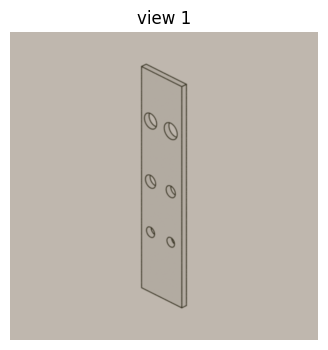

In [ ]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

# 1. Build single-sample DataLoader
loader = DataLoader(train_os, batch_size=1, shuffle=True, collate_fn=collator)

# 2. Get one batch
batch = next(iter(loader))
pv = batch["pixel_values"]        # [1, slots, 3, H, W]

# 3. De-normalize (CLIP mean/std)
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073])[None,:,None,None]
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711])[None,:,None,None]

# 4. Restore and convert to H×W×3
imgs = (pv[0] * std + mean).permute(0,2,3,1).cpu().numpy()
num_imgs = imgs.shape[0]

# 5. Visualize each image
for i in range(num_imgs):
    plt.figure(figsize=(4,4))
    plt.imshow(imgs[i].clip(0,1))
    plt.title(f"view {i+1}")
    plt.axis("off")
plt.show()


In [ ]:
trainer.train()

{'loss': 0.3541, 'grad_norm': 12.492897987365723, 'learning_rate': 0.0, 'epoch': 0.046511627906976744}
📝 Step 1 | Train Loss: 0.3541
{'loss': 0.356, 'grad_norm': 12.76868724822998, 'learning_rate': 2.8571428571428573e-06, 'epoch': 0.09302325581395349}
📝 Step 2 | Train Loss: 0.3560
{'loss': 0.2974, 'grad_norm': 9.805418968200684, 'learning_rate': 5.7142857142857145e-06, 'epoch': 0.13953488372093023}
📝 Step 3 | Train Loss: 0.2974
{'loss': 0.2073, 'grad_norm': 7.607190132141113, 'learning_rate': 0.0, 'epoch': 0.0392156862745098}
📝 Step 1 | Train Loss: 0.2073
{'loss': 0.2062, 'grad_norm': 7.43522834777832, 'learning_rate': 2.5e-06, 'epoch': 0.0784313725490196}
📝 Step 2 | Train Loss: 0.2062
{'loss': 0.1768, 'grad_norm': 6.076301574707031, 'learning_rate': 5e-06, 'epoch': 0.11764705882352941}
📝 Step 3 | Train Loss: 0.1768
{'loss': 0.1383, 'grad_norm': 3.624563217163086, 'learning_rate': 7.500000000000001e-06, 'epoch': 0.1568627450980392}
📝 Step 4 | Train Loss: 0.1383
{'loss': 0.0991, 'grad_n

TrainOutput(global_step=78, training_loss=0.01712653389534889, metrics={'train_runtime': 2254.1792, 'train_samples_per_second': 0.339, 'train_steps_per_second': 0.035, 'total_flos': 5.520868999658074e+16, 'train_loss': 0.01712653389534889})

In [ ]:
import wandb
wandb.finish()

train/epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/grad_norm,██▇▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▃▁▂▃▆▇████████▇▇▇▇▆▆▆▆▅▅▄▄▄▄▃▃▃▃▃▂▁▁▁▁▁
train/loss,██▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,5.520868999658074e+16
train/epoch,3
train/global_step,78
train/grad_norm,0.14373
train/learning_rate,0.0
train/loss,0.0021


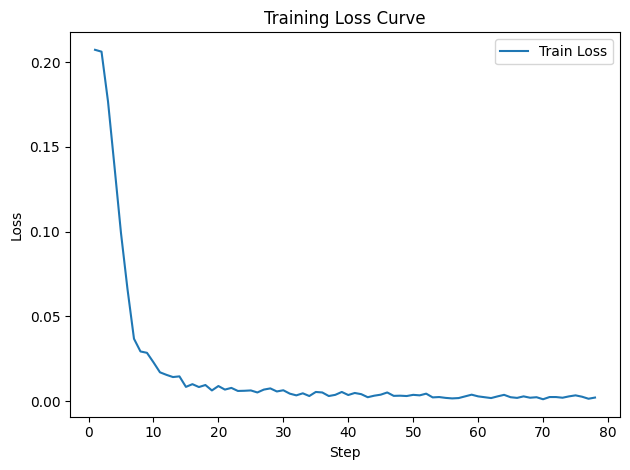

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# trainer.train() has finished
logs = trainer.state.log_history
df   = pd.DataFrame(logs)

# Keep only rows with loss
df_train = df[df["loss"].notnull()]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()


# Two-step fine-tuning model - separate image input

In [ ]:
# 1. Specify save path
output_path = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-10picture"

# 2. Save current Trainer model weights (including LoRA adapter) and tokenizer config
trainer.save_model(output_path)
trainer.tokenizer.save_pretrained(output_path)

# 3. Save training state (optimizer, lr_scheduler, global_step, rng state, etc.)
trainer.save_state()

print(f"✅ Fully saved to {output_path}, directory includes model weights, tokenizer files, and training states such as optimizer.pt, scheduler.pt, trainer_state.json, rng_state.pth")


# **Test in DatasetA**

# Original mode(EA1)

In [ ]:
import os, re, json, random, gc, torch, pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───────── Basic setup ─────────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS  = 256
BATCH_SIZE  = 5
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket",
               "Closed Pocket", "Chamfer", "Fillet"]

# ───────── Helper functions ─────────
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1: return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += ch == "{"
        depth -= ch == "}"
        if depth == 0: return raw[start:i+1]
    return raw[start:]

def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.I)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

def features_to_dict(feature_list):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        n = item.get("feature_name")
        if n in d:
            d[n]["exists"] = bool(item.get("exists", False))
            try:
                d[n]["quantity"] = int(item.get("quantity", 0))
            except: pass
    return d

# ───────── 1. Model ─────────
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model); model.eval()

# ───────── 2. Collator ─────────
collator = UnslothVisionDataCollator(
    model, tokenizer, max_seq_length=4096
)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ───────── 3. Dataset ─────────
dataset = test_dataset                      # ← your test set
idxs = list(range(len(dataset)))
random.seed(42); random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ───────── 4. Inference & statistics ─────────
rows, skip_count = [], 0

for s in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[s:s+BATCH_SIZE]

    # ---- Build input ----
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_c = []
            for e in m["content"]:
                if e["type"] == "text":
                    new_c.append({"type":"text",
                                  "text":clean_text(e["text"], IMAGE_TOKEN)})
                else:
                    new_c.append(e)
            cleaned.append({"role": m["role"], "content": new_c})
        inputs.append({"messages": cleaned})

    # ---- Inference ----
    batch = {k: v.to(model.device) for k, v in collator(inputs).items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**batch,
                             max_new_tokens=MAX_TOKENS,
                             eos_token_id=tokenizer.eos_token_id,
                             pad_token_id=tokenizer.pad_token_id,
                             do_sample=False)
    preds = tokenizer.batch_decode(out[:, inp_len:], skip_special_tokens=True)

    # ---- Parse results ----
    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)

        try:
            gt   = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_f = features_to_dict(gt.get("identified_features", []))
            pr_f = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1                      # ← mark parse failure
            gt   = json.loads(gt_txt)            # GT is always valid
            gt_f = features_to_dict(gt.get("identified_features", []))
            pr_f = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f+"_gt"]          = gt_f[f]["quantity"]
            row[f+"_pred"]        = pr_f[f]["quantity"]
            row[f+"_exists_gt"]   = gt_f[f]["exists"]
            row[f+"_exists_pred"] = pr_f[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    del batch, out, preds; gc.collect(); torch.cuda.empty_cache()

# ───────── 5. Evaluation metrics ─────────
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

# Basic match
for f in TYPE_FIELDS:
    df[f+"_match"]        = df[f+"_gt"] == df[f+"_pred"]
    df[f+"_exists_match"] = df[f+"_exists_gt"] == df[f+"_exists_pred"]
keys = [f+"_match" for f in TYPE_FIELDS]+[f+"_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[keys].all(axis=1)

# --- Summary ---
exact_acc     = df["exact_match"].mean()*100
numeric_acc   = df[[f+"_match" for f in TYPE_FIELDS]].mean(axis=1).mean()*100
existence_acc = df[[f+"_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean()*100
feature_acc   = df[keys].mean(axis=1).mean()*100

print(f"▶ Exact Match      : {exact_acc:.2f}%")
print(f"▶ Numeric Acc      : {numeric_acc:.2f}%")
print(f"▶ Existence Acc    : {existence_acc:.2f}%")
print(f"▶ Feature-level    : {feature_acc:.2f}%")

# --- FNA & FQA ---
tp_name = sum((df[f+"_exists_pred"] & df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f+"_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name/total_gt_names*100 if total_gt_names else float("nan")

tp_qty = df.apply(lambda r: sum(min(r[f+"_gt"], r[f+"_pred"]) for f in TYPE_FIELDS), axis=1).sum()
total_gt_qty = df[[f+"_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty/total_gt_qty*100 if total_gt_qty else float("nan")

print(f"▶ FNA  : {fna:.2f}%")
print(f"▶ FQA  : {fqa:.2f}%")

# ───────── Name & Quantity fine-grained metrics ─────────

# 1) Name level: TP / FP / FN
tp_name = sum((df[f+"_exists_pred"] &  df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f+"_exists_pred"] & ~df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f+"_exists_pred"] &  df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) else float("nan")
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) else float("nan")
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) else float("nan"))

# 2) Quantity level
pred_qty_total = df[[f+"_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f+"_pred"] - r[f+"_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
halluc_rate = halluc_qty / pred_qty_total * 100 if pred_qty_total else float("nan")

total_abs_error = df.apply(
    lambda r: sum(abs(r[f+"_pred"] - r[f+"_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

fn_qty = df.apply(
    lambda r: sum(max(r[f+"_gt"] - r[f+"_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
under_report_rate = fn_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

# 3) Quantity Precision / Recall / F1
total_pred_qty = pred_qty_total
q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   else float("nan")
quantity_f1 = (2 * q_precision * q_recall / (q_precision + q_recall)
               if (q_precision + q_recall) else float("nan"))

# 4) Overall score (weighted by α between Name F1 and Quantity F1)
alpha = 0.5        # adjust if needed
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 5) Print results
print("──────────────────────────────────────────")
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_report_rate:.2f}%")
print(f"▶ Quantity Precision   : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1          : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}) : {overall_score:.2f}%")
print("──────────────────────────────────────────")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:   2%|▎         | 1/40 [00:43<28:28, 43.80s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "name": "Through Hole"
  }

--- Sample 187 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
     

Evaluating:   5%|▌         | 2/40 [01:27<27:36, 43.60s/it]


--- Sample 121 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Chamfer",
            "exists": tru

...


--- Sample 108 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "name": "Through Hole"
  }

--- Sample 151 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
   

Evaluating:  98%|█████████▊| 39/40 [28:08<00:43, 43.53s/it]

[⚠️ Parse fail idx=26] raw='*Image description: The image shows six different views of a cylindrical part. The first view is a top-down perspective. The second view is a side view. The third view is a perspective view with two holes. The fourth view is a side view. The fifth view is a perspective view with a slot. The sixth view is a top-down perspective.*\n\n```json\n{\n    "identified_features": [\n        {\n            "feature_name": "Through Hole",\n            "exists": true,\n            "quantity": 2\n        },\n        {\n            "feature_name": "Blind Hole",\n            "exists": true,\n            "quantity": 2\n        },\n        {\n            "feature_name": "Chamfer",\n            "exists": false,\n            "quantity": 0\n        },\n        {\n            "feature_name": "Fillet",\n            "exists": false,\n            "quantity": 0\n        },\n        {\n            "feature_name": "Opened Pocket",\n            "exists": false,\n            "quantity": 

Evaluating: 100%|██████████| 40/40 [28:52<00:00, 43.30s/it]


--- Sample 70 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Blind Hole",
            "exists": t

# One-step fine-tuning model(EA2)

In [ ]:
import os, re, json, random, gc, torch, pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Silence logs & clear GPU cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparameters & Config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket",
               "Closed Pocket", "Chamfer", "Fillet"]

# ====== Helper functions ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1: return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += ch == "{"
        depth -= ch == "}"
        if depth == 0: return raw[start:i+1]
    return raw[start:]

def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.I)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

def features_to_dict(feats):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feats:
        n = item.get("feature_name")
        if n in d:
            d[n]["exists"] = bool(item.get("exists", False))
            try:
                d[n]["quantity"] = int(item.get("quantity", 0))
            except: pass
    return d

# ====== 1. Model ======
model, tokenizer = FastVisionModel.from_pretrained(
    "/content/drive/MyDrive/fine_tuned_model-gemma-twostep",
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model); model.eval()

# ====== 2. Collator ======
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False
IMG_TOK = getattr(collator, "image_token", "<image>")

# ====== 3. Dataset ======
dataset = test_dataset
idxs = list(range(len(dataset))); random.seed(42); random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference ======
rows, skip_count = [], 0

for s in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[s:s+BATCH_SIZE]
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            cont = []
            for e in m["content"]:
                if e["type"] == "text":
                    cont.append({"type":"text", "text":clean_text(e["text"], IMG_TOK)})
                else:
                    cont.append(e)
            cleaned.append({"role": m["role"], "content": cont})
        inputs.append({"messages": cleaned})

    batch = {k:v.to(model.device) for k,v in collator(inputs).items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**batch,
                             max_new_tokens=MAX_TOKENS,
                             eos_token_id=tokenizer.eos_token_id,
                             pad_token_id=tokenizer.pad_token_id,
                             do_sample=False)
    preds = tokenizer.batch_decode(out[:, inp_len:], skip_special_tokens=True)

    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)

        try:
            gt   = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_f = features_to_dict(gt.get("identified_features", []))
            pr_f = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1
            gt   = json.loads(gt_txt)
            gt_f = features_to_dict(gt.get("identified_features", []))
            pr_f = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f+"_gt"]          = gt_f[f]["quantity"]
            row[f+"_pred"]        = pr_f[f]["quantity"]
            row[f+"_exists_gt"]   = gt_f[f]["exists"]
            row[f+"_exists_pred"] = pr_f[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    del batch, out, preds; gc.collect(); torch.cuda.empty_cache()

# ====== 5. Metrics ======
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

for f in TYPE_FIELDS:
    df[f+"_match"]        = df[f+"_gt"] == df[f+"_pred"]
    df[f+"_exists_match"] = df[f+"_exists_gt"] == df[f+"_exists_pred"]
keys = [f+"_match" for f in TYPE_FIELDS]+[f+"_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[keys].all(axis=1)

exact_acc     = df["exact_match"].mean()*100
numeric_acc   = df[[f+"_match" for f in TYPE_FIELDS]].mean(axis=1).mean()*100
existence_acc = df[[f+"_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean()*100
feature_acc   = df[keys].mean(axis=1).mean()*100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    print(f"   {f:8}: {df[f+'_match'].mean()*100:5.2f}% / {df[f+'_exists_match'].mean()*100:5.2f}%")

# ---- FNA / FQA ----
tp_name = sum((df[f+"_exists_pred"] & df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f+"_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name/total_gt_names*100 if total_gt_names else float("nan")

tp_qty = df.apply(lambda r: sum(min(r[f+"_gt"], r[f+"_pred"]) for f in TYPE_FIELDS), axis=1).sum()
total_gt_qty = df[[f+"_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty/total_gt_qty*100 if total_gt_qty else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {fqa:.2f}%")

# ---- Fine-grained & overall ----
fp_name = sum((df[f+"_exists_pred"] & ~df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f+"_exists_pred"] &  df[f+"_exists_gt"]).sum() for f in TYPE_FIELDS)

name_prec = tp_name/(tp_name+fp_name)*100 if (tp_name+fp_name) else float("nan")
name_rec  = tp_name/(tp_name+fn_name)*100 if (tp_name+fn_name) else float("nan")
name_f1   = 2*name_prec*name_rec/(name_prec+name_rec) if (name_prec+name_rec) else float("nan")

pred_qty_total = df[[f+"_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty = df.apply(lambda r: sum(max(r[f+"_pred"]-r[f+"_gt"],0) for f in TYPE_FIELDS), axis=1).sum()
halluc_rate = halluc_qty/pred_qty_total*100 if pred_qty_total else float("nan")

mae = df.apply(lambda r: sum(abs(r[f+"_pred"]-r[f+"_gt"]) for f in TYPE_FIELDS), axis=1).sum()/(len(df)*len(TYPE_FIELDS))
fn_qty = df.apply(lambda r: sum(max(r[f+"_gt"]-r[f+"_pred"],0) for f in TYPE_FIELDS), axis=1).sum()
under_rate = fn_qty/total_gt_qty*100 if total_gt_qty else float("nan")

q_prec = tp_qty/pred_qty_total*100 if pred_qty_total else float("nan")
q_rec  = tp_qty/total_gt_qty  *100 if total_gt_qty   else float("nan")
q_f1   = 2*q_prec*q_rec/(q_prec+q_rec) if (q_prec+q_rec) else float("nan")

alpha = 0.5
overall = alpha*name_f1 + (1-alpha)*q_f1

print("──────────────────────────────────────────")
print(f"▶ Name Precision       : {name_prec:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_rec:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_rate:.2f}%")
print(f"▶ Quantity Precision   : {q_prec:.2f}%")
print(f"▶ Quantity Recall      : {q_rec:.2f}%")
print(f"▶ Quantity F1          : {q_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall:.2f}%")
print("──────────────────────────────────────────")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:  10%|█         | 1/10 [01:27<13:03, 87.03s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  20%|██        | 2/10 [02:17<08:44, 65.62s/it]


--- Sample 159 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

...


--- Sample 81 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  80%|████████  | 8/10 [07:20<01:42, 51.43s/it]


--- Sample 58 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating: 100%|██████████| 10/10 [09:01<00:00, 54.15s/it]


--- Sample 59 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

# Two-step fine-tuning model(EA3)

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Silence logs & clear GPU cache ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparameters & Config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = [
    "Through Hole", "Blind Hole", "Opened Pocket",
    "Closed Pocket", "Chamfer", "Fillet"
]

# ====== Helper functions ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = "\n".join(raw.splitlines()[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        depth += (ch == "{")
        depth -= (ch == "}")
        if depth == 0:
            return raw[start:i+1]
    return raw[start:]

def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    return re.sub(r"\n{2,}", "\n", txt).strip()

def features_to_dict(feature_list):
    d = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in d:
            d[name]["exists"] = bool(item.get("exists", False))
            try:
                d[name]["quantity"] = int(item.get("quantity", 0))
            except:
                pass
    return d

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-combinepicture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(
    model, tokenizer,
    max_seq_length=4096
)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Dataset prep ======
dataset = test_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collection ======
rows = []
skip_count = 0

for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start:start + BATCH_SIZE]
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for idx, raw in zip(batch_idxs, preds):
        gt_txt   = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = features_to_dict(pred.get("identified_features", []))
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            skip_count += 1
            gt = json.loads(gt_txt)
            gt_feats   = features_to_dict(gt.get("identified_features", []))
            pred_feats = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"]          = gt_feats[f]["quantity"]
            row[f + "_pred"]        = pred_feats[f]["quantity"]
            row[f + "_exists_gt"]   = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics & Evaluation ======
df = pd.DataFrame(rows)
print(f"✅ Collected {len(df)}/{len(dataset)} samples (parse-fail→all-wrong: {skip_count})")

# Basic match
for f in TYPE_FIELDS:
    df[f + "_match"]        = df[f + "_gt"] == df[f + "_pred"]
    df[f + "_exists_match"] = df[f + "_exists_gt"] == df[f + "_exists_pred"]
all_matches = [f + "_match" for f in TYPE_FIELDS] + [f + "_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Basic metrics
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f + "_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f + "_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean(axis=1).mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    print(f"   {f:8}: {df[f + '_match'].mean()*100:5.2f}% / {df[f + '_exists_match'].mean()*100:5.2f}%")

# FNA & FQA
tp_name = sum((df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f + "_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names else float("nan")

tp_qty = df.apply(lambda r: sum(min(r[f + "_gt"], r[f + "_pred"]) for f in TYPE_FIELDS), axis=1).sum()
total_gt_qty = df[[f + "_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {fqa:.2f}%")

# ───────── Fine-grained & Overall Score ─────────
fp_name = sum((df[f + "_exists_pred"] & ~df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f + "_exists_pred"] & df[f + "_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) else float("nan")
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) else float("nan")
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) else float("nan"))

pred_qty_total = df[[f + "_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(lambda r: sum(max(r[f + "_pred"] - r[f + "_gt"], 0) for f in TYPE_FIELDS), axis=1).sum()
halluc_rate    = halluc_qty / pred_qty_total * 100 if pred_qty_total else float("nan")

total_abs_error = df.apply(lambda r: sum(abs(r[f + "_pred"] - r[f + "_gt"]) for f in TYPE_FIELDS), axis=1).sum()
mae            = total_abs_error / (len(df) * len(TYPE_FIELDS))

fn_qty         = df.apply(lambda r: sum(max(r[f + "_gt"] - r[f + "_pred"], 0) for f in TYPE_FIELDS), axis=1).sum()
under_report_rate = fn_qty / total_gt_qty * 100 if total_gt_qty else float("nan")

quantity_precision = tp_qty / pred_qty_total * 100 if pred_qty_total else float("nan")
quantity_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   else float("nan")
quantity_f1        = (2 * quantity_precision * quantity_recall /
                      (quantity_precision + quantity_recall)
                      if (quantity_precision + quantity_recall) else float("nan"))

alpha = 0.5
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

print("────────────────────────────────────────────")
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {halluc_rate:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {under_report_rate:.2f}%")
print(f"▶ Quantity Precision   : {quantity_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {quantity_recall:.2f}%")
print(f"▶ Quantity F1          : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}) : {overall_score:.2f}%")
print("────────────────────────────────────────────")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 200 samples


Evaluating:  10%|█         | 1/10 [01:26<13:01, 86.87s/it]


--- Sample 66 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating:  20%|██        | 2/10 [02:17<08:43, 65.44s/it]


--- Sample 159 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

...


--- Sample 58 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  90%|█████████ | 9/10 [08:08<00:50, 50.77s/it]


--- Sample 86 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists"

Evaluating: 100%|██████████| 10/10 [08:58<00:00, 53.83s/it]


--- Sample 59 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists":

# **Tset on DatasetB**

# Two-step fine-tuning model - Stitch image input(EB6)

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Silence logs & clear VRAM ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# reduce memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & Config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 20
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract valid JSON ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaner ======
def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Convert identified_features list -> dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & set inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-combinepicture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Dataset prep ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collect results ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Forward pass
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # cleanup VRAM
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# number matching
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# existence matching
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (both qty + exists correct)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Metric calculation
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── FNA & FQA ───────────
# FNA: TP_name / total GT names
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: TP qty (sum of min(gt_qty, pred_qty)) / total GT qty
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Extra fine-grained error metrics =====

# 1. Name-level
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# Print metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Quantity-level F1 & Overall Score =====

# 1. Quantity Precision & Recall (reuse tp_qty, total_gt_qty, total_pred_qty)
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Overall Score
alpha = 0.5  # weight for name vs quantity, adjustable
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference & Evaluation on 49 samples


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  33%|███▎      | 1/3 [01:16<02:33, 76.92s/it]


--- Sample 42 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 16
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 11
        },
        {
            "feature_name": "Blind Hole",
            "exists

Evaluating:  67%|██████▋   | 2/3 [02:08<01:01, 61.93s/it]


--- Sample 34 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating: 100%|██████████| 3/3 [02:56<00:00, 58.93s/it]

✅ Collected 49/49 valid samples
▶ Exact Match        : 4.08%
▶ Numeric Acc        : 62.24%
▶ Existence (Type)   : 79.93%
▶ Feature‑level      : 71.09%
▶ Per‑field Acc (qty/exist):
   Through Hole: 32.65% / 87.76%
   Blind Hole: 75.51% / 81.63%
   Opened Pocket: 34.69% / 63.27%
   Closed Pocket: 83.67% / 87.76%
   Chamfer : 89.80% / 91.84%
   Fillet  : 57.14% / 67.35%
▶ Feature Name Accuracy (FNA): 77/110 = 70.00%
▶ Feature Quantity Accuracy (FQA): 168/302 = 55.63%
▶ Name Precision       : 74.76%
▶ Name Recall (FNA)    : 70.00%
▶ Name F1              : 72.30%
▶ Hallucination Rate   : 34.38%
▶ Mean Absolute Error  : 0.755
▶ Under-report Rate    : 44.37%
▶ Quantity Precision  : 65.62%
▶ Quantity Recall (FQA): 55.63%
▶ Quantity F1         : 60.22%
▶ Overall Score (α=0.5): 66.26%


In [ ]:
import torch
import gc

# If there are still large tensors being held, delete them first

# 2. Force Python garbage collection
gc.collect()

# 3. Tell PyTorch to release cached CUDA memory
torch.cuda.empty_cache()

# 4. (Optional) Check current GPU memory usage
print(torch.cuda.memory_summary(device=0, abbreviated=True))


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   4385 MiB |   4385 MiB |   8481 MiB |   4096 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   4385 MiB |   4385 MiB |   8481 MiB |   4096 MiB |
|---------------------------------------------------------------------------|
| Requested memory      |   4352 MiB |   4352 MiB |   8443 MiB |   4091 MiB |
|---------------------------------------------------------------

# Two-step fine-tuning model - Separate image input(EB5)

In [ ]:
import os
import re
import json
import random
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

# ───── Silence logs & clear GPU memory ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
# Reduce memory fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# ====== Hyperparams & Config ======
MAX_TOKENS  = 256
BATCH_SIZE  = 10
VERBOSE     = True
TYPE_FIELDS = ["Through Hole", "Blind Hole", "Opened Pocket", "Closed Pocket", "Chamfer", "Fillet"]
NUM_FIELDS  = TYPE_FIELDS

# ====== Helper: extract full JSON ======
def extract_json(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1])
    start = raw.find("{")
    if start == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[start : i + 1]
    return raw[start:]

# ====== Text cleaning ======
def clean_text(txt: str, image_token="<image>") -> str:
    txt = re.sub(r"\[/?INST\]", "", txt, flags=re.IGNORECASE)
    txt = txt.replace(image_token, "")
    txt = re.sub(r"\n{2,}", "\n", txt).strip()
    return txt

# ====== Utility: convert identified_features list to dict ======
def features_to_dict(feature_list):
    feat_dict = {f: {"exists": False, "quantity": 0} for f in TYPE_FIELDS}
    for item in feature_list:
        name = item.get("feature_name")
        if name in feat_dict:
            feat_dict[name]["exists"] = bool(item.get("exists", False))
            try:
                feat_dict[name]["quantity"] = int(item.get("quantity", 0))
            except:
                feat_dict[name]["quantity"] = 0
    return feat_dict

# ====== 1. Load model & switch to inference mode ======
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-10picture"
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir, load_in_4bit=True, device_map="auto"
)
FastVisionModel.for_inference(model)
model.eval()

from transformers.cache_utils import Cache

def _patched_max_cache_len(self):
    # Always return a fixed constant
    # 4096 > your max context 3053 / Gemma3 max ~3300
    return 4096

# Override original property
Cache.max_cache_len = property(_patched_max_cache_len)

print("[✓] Cache.max_cache_len has been fixed to 4096, use_cache=True no longer reports errors or shape conflicts")

# ====== 2. Build collator ======
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False
IMAGE_TOKEN = getattr(collator, "image_token", "<image>")

# ====== 3. Data preparation ======
dataset = test_contrast1000_dataset
idxs = list(range(len(dataset)))
random.seed(42)
random.shuffle(idxs)
print(f"✅ Inference & Evaluation on {len(dataset)} samples")

# ====== 4. Inference & collection ======
rows = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Evaluating"):
    batch_idxs = idxs[start : start + BATCH_SIZE]

    # Build inputs
    inputs = []
    for i in batch_idxs:
        msgs = [m for m in dataset[i]["messages"] if m["role"] != "assistant"]
        cleaned = []
        for m in msgs:
            new_content = []
            for elem in m["content"]:
                if elem.get("type") == "text":
                    new_content.append({
                        "type": "text",
                        "text": clean_text(elem["text"], IMAGE_TOKEN)
                    })
                else:
                    new_content.append(elem)
            cleaned.append({"role": m["role"], "content": new_content})
        inputs.append({"messages": cleaned})

    # Run inference
    batch = collator(inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]
    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )
    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    # Parse & collect
    for idx, raw in zip(batch_idxs, preds):
        gt_txt = dataset[idx]["messages"][-1]["content"][0]["text"].strip()
        pred_txt = extract_json(raw)
        try:
            gt = json.loads(gt_txt)
            pred = json.loads(pred_txt)
        except json.JSONDecodeError:
            if VERBOSE:
                print(f"[⚠️ Parse fail idx={idx}] raw={raw!r}")
            continue

        gt_feats = features_to_dict(gt.get("identified_features", []))
        pred_feats = features_to_dict(pred.get("identified_features", []))

        row = {}
        for f in TYPE_FIELDS:
            row[f + "_gt"] = gt_feats[f]["quantity"]
            row[f + "_pred"] = pred_feats[f]["quantity"]
            row[f + "_exists_gt"] = gt_feats[f]["exists"]
            row[f + "_exists_pred"] = pred_feats[f]["exists"]
        rows.append(row)

        if VERBOSE:
            print(f"\n--- Sample {idx} ---")
            print("GT  :", gt_txt)
            print("PRED:", pred_txt)

    # Free GPU memory
    del batch, out_ids, preds
    gc.collect()
    torch.cuda.empty_cache()

# ====== 5. Metrics ======
df = pd.DataFrame(rows)
n = len(df)
print(f"✅ Collected {n}/{len(dataset)} valid samples")

# Numeric match
for nf in NUM_FIELDS:
    df[f"{nf}_match"] = df[f"{nf}_gt"] == df[f"{nf}_pred"]
# Existence match
for f in TYPE_FIELDS:
    df[f"{f}_exists_match"] = df[f"{f}_exists_gt"] == df[f"{f}_exists_pred"]

# Exact Match (both quantity + existence)
all_matches = [f"{nf}_match" for nf in NUM_FIELDS] + [f"{f}_exists_match" for f in TYPE_FIELDS]
df["exact_match"] = df[all_matches].all(axis=1)

# Metric calculation
exact_acc     = df["exact_match"].mean() * 100
numeric_acc   = df[[f"{nf}_match" for nf in NUM_FIELDS]].mean(axis=1).mean() * 100
existence_acc = df[[f"{f}_exists_match" for f in TYPE_FIELDS]].mean(axis=1).mean() * 100
feature_acc   = df[all_matches].mean().mean() * 100

print(f"▶ Exact Match        : {exact_acc:.2f}%")
print(f"▶ Numeric Acc        : {numeric_acc:.2f}%")
print(f"▶ Existence (Type)   : {existence_acc:.2f}%")
print(f"▶ Feature-level      : {feature_acc:.2f}%")
print("▶ Per-field Acc (qty/exist):")
for f in TYPE_FIELDS:
    qty = df[f"{f}_match"].mean() * 100
    ex  = df[f"{f}_exists_match"].mean() * 100
    print(f"   {f:8}: {qty:5.2f}% / {ex:5.2f}%")

# ─────────── Added: FNA & FQA ───────────
# FNA: TP_name / total GT feature names
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
total_gt_names = sum(df[f"{f}_exists_gt"].sum() for f in TYPE_FIELDS)
fna = tp_name / total_gt_names * 100 if total_gt_names > 0 else float("nan")

# FQA: sum of min(gt_qty, pred_qty) / total GT qty
# Take per-sample per-feature min(gt, pred) as TP_qty
tp_qty = df.apply(
    lambda row: sum(min(row[f"{f}_gt"], row[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
fqa = tp_qty / total_gt_qty * 100 if total_gt_qty > 0 else float("nan")

print(f"▶ Feature Name Accuracy (FNA): {tp_name}/{total_gt_names} = {fna:.2f}%")
print(f"▶ Feature Quantity Accuracy (FQA): {tp_qty}/{total_gt_qty} = {fqa:.2f}%")

# ===== Added: finer-grained over-report/under-report metrics =====

# 1. Name-level metrics
tp_name = sum((df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fp_name = sum((df[f"{f}_exists_pred"] & ~df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)
fn_name = sum((~df[f"{f}_exists_pred"] & df[f"{f}_exists_gt"]).sum() for f in TYPE_FIELDS)

name_precision = tp_name / (tp_name + fp_name) * 100 if (tp_name + fp_name) > 0 else float('nan')
name_recall    = tp_name / (tp_name + fn_name) * 100 if (tp_name + fn_name) > 0 else float('nan')
name_f1        = (2 * name_precision * name_recall / (name_precision + name_recall)
                  if (name_precision + name_recall) > 0 else float('nan'))

# 2. Quantity-level metrics

## 2.1 Hallucination Rate (HR)
pred_qty_total = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()
halluc_qty     = df.apply(
    lambda r: sum(max(r[f"{f}_pred"] - r[f"{f}_gt"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
hr = halluc_qty / pred_qty_total * 100 if pred_qty_total > 0 else float('nan')

## 2.2 Mean Absolute Error (MAE)
total_abs_error = df.apply(
    lambda r: sum(abs(r[f"{f}_pred"] - r[f"{f}_gt"]) for f in TYPE_FIELDS),
    axis=1
).sum()
mae = total_abs_error / (len(df) * len(TYPE_FIELDS))

## 2.3 Under-report Rate (UR)
fn_qty       = df.apply(
    lambda r: sum(max(r[f"{f}_gt"] - r[f"{f}_pred"], 0) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty = df[[f"{f}_gt" for f in TYPE_FIELDS]].sum().sum()
ur = fn_qty / total_gt_qty * 100 if total_gt_qty > 0 else float('nan')

# 3. Print all new metrics
print(f"▶ Name Precision       : {name_precision:.2f}%")
print(f"▶ Name Recall (FNA)    : {name_recall:.2f}%")
print(f"▶ Name F1              : {name_f1:.2f}%")
print(f"▶ Hallucination Rate   : {hr:.2f}%")
print(f"▶ Mean Absolute Error  : {mae:.3f}")
print(f"▶ Under-report Rate    : {ur:.2f}%")

# ===== Added: Quantity F1 & overall score =====

# 1. Compute Quantity Precision & Quantity Recall (FQA)
# tp_qty, total_gt_qty, total_pred_qty already computed earlier
# If not, recompute like this:
tp_qty = df.apply(
    lambda r: sum(min(r[f"{f}_gt"], r[f"{f}_pred"]) for f in TYPE_FIELDS),
    axis=1
).sum()
total_gt_qty   = df[[f"{f}_gt"   for f in TYPE_FIELDS]].sum().sum()
total_pred_qty = df[[f"{f}_pred" for f in TYPE_FIELDS]].sum().sum()

q_precision = tp_qty / total_pred_qty * 100 if total_pred_qty > 0 else float("nan")
q_recall    = tp_qty / total_gt_qty   * 100 if total_gt_qty   > 0 else float("nan")

# 2. Compute Quantity F1
quantity_f1 = (
    2 * q_precision * q_recall / (q_precision + q_recall)
    if (q_precision + q_recall) > 0 else float("nan")
)

# 3. Compute overall score
alpha = 0.5  # weight for name vs quantity
overall_score = alpha * name_f1 + (1 - alpha) * quantity_f1

# 4. Print
print(f"▶ Quantity Precision  : {q_precision:.2f}%")
print(f"▶ Quantity Recall (FQA): {q_recall:.2f}%")
print(f"▶ Quantity F1         : {quantity_f1:.2f}%")
print(f"▶ Overall Score (α={alpha}): {overall_score:.2f}%")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
[✓] Cache.max_cache_len has been fixed to 4096, use_cache=True no longer reports errors or shape conflicts
✅ Inference & Evaluation on 49 samples


Evaluating:  20%|██        | 1/5 [01:11<04:44, 71.21s/it]


--- Sample 25 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 7
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exists":

Evaluating:  40%|████      | 2/5 [02:18<03:26, 68.82s/it]


--- Sample 31 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 4
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 4
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

...


--- Sample 42 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 16
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 11
        },
        {
            "feature_name": "Blind Hole",
            "exists

Evaluating:  80%|████████  | 4/5 [04:11<01:00, 60.60s/it]


--- Sample 45 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": true,
            "quantity": 1
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 5
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

Evaluating: 100%|██████████| 5/5 [05:07<00:00, 61.40s/it]


--- Sample 34 ---
GT  : {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": true,
            "quantity": 1
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}
PRED: {
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": 

# **Test on 15 additional test models**

# One-step fine-tuning model

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # if using HF datasets

# ───── 0. Environment setup ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 20

# ───── 1. Extract outermost JSON ─────
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ───── 2. Load model ─────
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep"  # ← update
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ───── 3. Collator ─────
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ───── 4. Dataset ─────
dataset = contrast_dataset                                    # ← update
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ───── 5. Inference ─────
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # optional: print immediately
        # print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ───── 6. Ground truth table (Hole merged) ─────
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":            [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ───── 7. Parse predictions → 0 / 1 ─────
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))
     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ───── 8. Merge & handle NaN ─────
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ───── 9. Debug print ─────
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ───── 10. Explicit loop for Recall calculation ─────
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ───── 11. Results ─────
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample-Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing: 100%|██████████| 1/1 [00:48<00:00, 48.44s/it]


≡≡ count of positive examples (GT vs PRED) ≡≡
Pocket_Closed    GT= 5 | PRED= 1
Pocket_Opened    GT=11 | PRED=14
Hole             GT= 9 | PRED=10
Corner_Fillet    GT= 2 | PRED= 0
Corner_Chamfer   GT= 1 | PRED= 1

Micro Recall:          71.43%
Sample‑Average Recall: 81.11%


# Two-step fine-tuning model - Stitch image input

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # if using HF datasets

# ───── 0. Environment setup ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 20

# ───── 1. Extract outermost JSON ─────
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ───── 2. Load model ─────
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-combinepicture"  # ← update
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ───── 3. Collator ─────
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ───── 4. Dataset ─────
dataset = contrast_dataset                                    # ← update
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ───── 5. Inference ─────
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # optional: print immediately
        # print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ───── 6. Ground truth table (Hole merged) ─────
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":            [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ───── 7. Parse predictions → 0 / 1 ─────
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))
     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ───── 8. Merge & handle NaN ─────
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ───── 9. Debug print ─────
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ───── 10. Explicit loop for Recall calculation ─────
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ───── 11. Results ─────
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample-Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing: 100%|██████████| 1/1 [00:48<00:00, 48.82s/it]


≡≡ count of positive examples (GT vs PRED) ≡≡
Pocket_Closed    GT= 5 | PRED= 1
Pocket_Opened    GT=11 | PRED=13
Hole             GT= 9 | PRED= 9
Corner_Fillet    GT= 2 | PRED= 2
Corner_Chamfer   GT= 1 | PRED= 0

Micro Recall:          71.43%
Sample‑Average Recall: 80.00%


# Two-step fine-tuning model - Separately input images

In [ ]:
# =========================================
#  Inference + Parsing + Micro / Sample Recall Calculation
# =========================================
import os, json, gc, re, torch, pandas as pd, numpy as np
from tqdm import tqdm
from transformers import logging
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_from_disk   # if using HF datasets

# ───── 0. Environment setup ─────
logging.set_verbosity_error()
torch.cuda.empty_cache()
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

MAX_TOKENS = 256
BATCH_SIZE = 5

# ───── 1. Extract outermost JSON ─────
def extract_json(raw: str) -> str:
    raw = raw.strip()
    s = raw.find("{")
    if s == -1:
        return raw
    depth = 0
    for i, ch in enumerate(raw[s:], s):
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return raw[s:i+1]
    return raw[s:]

# ───── 2. Load model ─────
adapter_dir = "/content/drive/MyDrive/fine_tuned_model-gemma-twostep-10picture"  # ← update
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_dir,
    load_in_4bit=True,
    device_map="auto",
)
FastVisionModel.for_inference(model)
model.eval()

# ───── 3. Collator ─────
collator = UnslothVisionDataCollator(model, tokenizer, max_seq_length=4096)
collator.truncation = False

# ───── 4. Dataset ─────
dataset = contrast_dataset                                    # ← update
idxs = list(range(len(dataset)))
print(f"✅ Inference on {len(idxs)} samples")

# ───── 5. Inference ─────
results = []
for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="Inferencing"):
    batch_idxs = idxs[start:start+BATCH_SIZE]
    batch_inputs = [{"messages": dataset[i]["messages"]} for i in batch_idxs]

    batch = collator(batch_inputs)
    batch = {k: v.to(model.device) for k, v in batch.items()}
    inp_len = batch["input_ids"].shape[-1]

    with torch.no_grad():
        out_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TOKENS,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=False,
            num_beams=1,
        )

    preds = tokenizer.batch_decode(out_ids[:, inp_len:], skip_special_tokens=True)

    for ds_idx, raw in zip(batch_idxs, preds):
        rec = {
            "sample_idx": ds_idx + 1,
            "pred_json": extract_json(raw),
        }
        results.append(rec)
        # optional: print immediately
        print(f"\n--- Sample {rec['sample_idx']} ---\n{rec['pred_json']}")

    del batch, out_ids, preds
    gc.collect(); torch.cuda.empty_cache()

# ───── 6. Ground truth table (Hole merged) ─────
gt_df = pd.DataFrame({
    "sample_idx":         list(range(1, 16)),
    "Pocket_Closed_gt":   [0,0,1,0,0,0,1,1,0,2,3,0,0,0,0],
    "Pocket_Opened_gt":   [1,1,1,2,2,3,3,2,6,3,3,0,0,0,0],
    "Hole_gt":            [0,0,0,0,0,1,3,3,2,2,0,2,1,1,1],
    "Corner_Fillet_gt":   [0,0,0,0,0,0,0,1,0,0,3,0,0,0,0],
    "Corner_Chamfer_gt":  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
})

features = ["Pocket_Closed","Pocket_Opened","Hole","Corner_Fillet","Corner_Chamfer"]

# ───── 7. Parse predictions → 0 / 1 ─────
def parse_pred(js_str: str):
    out = dict.fromkeys(features, 0)
    js = json.loads(js_str)
    for feat in js.get("identified_features", []):
        name = feat["feature_name"]
        qty  = feat.get("quantity", 0)
        if "Closed Pocket" in name:   out["Pocket_Closed"]  = qty
        if "Opened Pocket" in name:   out["Pocket_Opened"]  = qty
        if "Through Hole" in name or "Blind Hole" in name:
            out["Hole"] += qty
        if "Fillet" in name:          out["Corner_Fillet"]  = qty
        if "Chamfer" in name:         out["Corner_Chamfer"] = qty
    return {k: int(v > 0) for k, v in out.items()}

pred_df = pd.DataFrame(
    [dict(sample_idx=rec["sample_idx"], **parse_pred(rec["pred_json"]))
     for rec in results]
).rename(columns={f: f+"_pred" for f in features})

# ───── 8. Merge & handle NaN ─────
df = gt_df.merge(pred_df, on="sample_idx", how="left")
for f in features:
    df[f+"_pred"] = df[f+"_pred"].fillna(0).astype(int)

# ───── 9. Debug print ─────
print("\n≡≡ count of positive examples (GT vs PRED) ≡≡")
for f in features:
    gt_pos   = int((df[f+"_gt"]   > 0).sum())
    pred_pos = int((df[f+"_pred"] > 0).sum())
    print(f"{f:16s} GT={gt_pos:2d} | PRED={pred_pos:2d}")

# ───── 10. Explicit loop for Recall calculation ─────
tp = 0
total_pos = 0
sample_recalls = []

for _, row in df.iterrows():
    gt_present   = {f: int(row[f + "_gt"]   > 0) for f in features}
    pred_present = {f: int(row[f + "_pred"] > 0) for f in features}

    tp_sample = sum(1 for f in features if gt_present[f] and pred_present[f])
    gt_sample = sum(gt_present.values())

    tp += tp_sample
    total_pos += gt_sample

    if gt_sample > 0:
        sample_recalls.append(tp_sample / gt_sample)

micro_recall      = tp / total_pos
sample_avg_recall = float(np.mean(sample_recalls))

# ───── 11. Results ─────
print(f"\nMicro Recall:          {micro_recall:.2%}")
print(f"Sample-Average Recall: {sample_avg_recall:.2%}")


==((====))==  Unsloth 2025.7.11: Fast Gemma3 patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Inference on 15 samples


Inferencing:  33%|███▎      | 1/3 [00:51<01:42, 51.07s/it]


--- Sample 1 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 2 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "ex

Inferencing:  67%|██████▋   | 2/3 [01:41<00:50, 50.94s/it]


--- Sample 6 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 2
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 7 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Blind Hole",
            "exi

Inferencing: 100%|██████████| 3/3 [02:33<00:00, 51.00s/it]


--- Sample 11 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Blind Hole",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Opened Pocket",
            "exists": true,
            "quantity": 3
        },
        {
            "feature_name": "Closed Pocket",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Chamfer",
            "exists": false,
            "quantity": 0
        },
        {
            "feature_name": "Fillet",
            "exists": false,
            "quantity": 0
        }
    ]
}

--- Sample 12 ---
{
    "identified_features": [
        {
            "feature_name": "Through Hole",
            "exists": true,
            "quantity": 6
        },
        {
            "feature_name": "Blind Hole",
            "e